In [0]:
import json
from datetime import timedelta

import pyspark.sql.functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
from pyspark.sql.functions import broadcast
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.stat import Correlation

# Load data

**Section summary:** Configure `BASE_GROUP` and read the joined flight–weather table from DBFS. The next code cells list available group assets and load `kenzie_full_df_joined.parquet`.

After a full run, expect about **31.7M rows and 98 columns**. Paths and row counts should be re-checked if the upstream join changes.

In [0]:
BASE       = "dbfs:/mnt/mids-w261"
BASE_GROUP = "dbfs:/student-groups/Group_01_02"
TARGET     = "DEP_DEL15"

# List available files
display(dbutils.fs.ls(BASE_GROUP))

path,name,size,modificationTime
dbfs:/student-groups/Group_01_02/5Y_2020/,5Y_2020/,0,1776284827866
dbfs:/student-groups/Group_01_02/5Y_LR/,5Y_LR/,0,1776284827866
dbfs:/student-groups/Group_01_02/5Y_MLP/,5Y_MLP/,0,1776284827867
dbfs:/student-groups/Group_01_02/EDA_Plots_Gallery_Phase2_3.ipynb,EDA_Plots_Gallery_Phase2_3.ipynb,456,1776232137000
dbfs:/student-groups/Group_01_02/GBT_confusion_matrix.png,GBT_confusion_matrix.png,7137,1763941199000
dbfs:/student-groups/Group_01_02/MLP_checkpoint2/,MLP_checkpoint2/,0,1776284827867
dbfs:/student-groups/Group_01_02/X_test_kenzie_transformer.npy,X_test_kenzie_transformer.npy,2496403328,1776030521000
dbfs:/student-groups/Group_01_02/X_train_kenzie_transformer.npy,X_train_kenzie_transformer.npy,7479599728,1776030501000
dbfs:/student-groups/Group_01_02/X_val_kenzie_transformer.npy,X_val_kenzie_transformer.npy,2531815328,1776030515000
dbfs:/student-groups/Group_01_02/chart_delay_by_hour.csv,chart_delay_by_hour.csv,729,1775443962000


In [0]:
df_raw = spark.read.parquet(f"{BASE_GROUP}/kenzie_full_df_joined.parquet").cache()
print(f"Loaded kenzie_full_df_joined: {df_raw.count():,} rows, {len(df_raw.columns)} cols")

Loaded kenzie_full_df_joined: 31,746,841 rows, 104 cols


In [0]:
df_raw.printSchema()

root
 |-- QUARTER: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- FL_DATE: string (nullable = true)
 |-- OP_UNIQUE_CARRIER: string (nullable = true)
 |-- OP_CARRIER_AIRLINE_ID: integer (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- TAIL_NUM: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN_AIRPORT_ID: integer (nullable = true)
 |-- ORIGIN_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- ORIGIN_CITY_MARKET_ID: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- ORIGIN_CITY_NAME: string (nullable = true)
 |-- ORIGIN_STATE_ABR: string (nullable = true)
 |-- ORIGIN_STATE_FIPS: integer (nullable = true)
 |-- ORIGIN_STATE_NM: string (nullable = true)
 |-- ORIGIN_WAC: integer (nullable = true)
 |-- DEST_AIRPORT_ID: integer (nullable = true)
 |-- DEST_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- DEST_CITY_MARKET_

# Leakage drop, schedule-only extensions, and split

**What this section does**

- **Leakage removal:** Drops post-departure / outcome fields (`DEP_TIME`, delay components, wheels/taxi, cancellation flags, etc.) so the model only sees information available at booking or scheduled departure time.
- **Deterministic basics:** `dep_hour`, morning/evening peak flags, `ROUTE`, and trace precipitation cleanup where applicable.
- **Phase 3.3 extensions (no label leakage):**
  - **US federal holidays:** `is_holiday`, `is_pre_holiday`, `is_post_holiday`, `is_holiday_weekend_adjacent` via a broadcast calendar join on `FL_DATE`.
  - **Scheduled congestion:** 2-hour CRS bins per origin and date; `origin_sched_count_prev2h` and `is_origin_busy_2h_before` using a **train-only** busy threshold (printed as the 90th percentile of prior-window counts).
- **Split:** 60 / 20 / 20 by calendar position `(MONTH, DAY_OF_MONTH)` — **before** dropping null labels in the Cleaning section.

**Section summary (from cell output):**  
`Split: Train 19,035,641 | Val 6,413,383 | Test 6,297,817`  
`Phase 3.3 extended: busy_prev2h threshold (train p90)=96.0`

After Cleaning, labeled row counts drop once null `DEP_DEL15` rows are removed (see **Cleaning**).

In [0]:
LEAKY = [
    "DEP_DELAY", "DEP_DELAY_NEW", "DEP_DELAY_GROUP",
    "DEP_TIME", "WHEELS_OFF", "WHEELS_ON", "TAXI_OUT", "TAXI_IN",
    "ARR_DELAY", "ARR_DELAY_NEW", "ARR_DELAY_GROUP", "ARR_TIME", "ARR_TIME_BLK",
    "ARR_DEL15", "ACTUAL_ELAPSED_TIME", "AIR_TIME",
    "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",
    "CANCELLED", "CANCELLATION_CODE", "DIVERTED",
    "FIRST_DEP_TIME", "TOTAL_ADD_GTIME", "LONGEST_ADD_GTIME", "DEP_TIME_BLK",
] + [c for c in df_raw.columns if c.startswith("DIV")]

df_clean = df_raw.drop(*[c for c in LEAKY if c in df_raw.columns])

# Step 2: Deterministic features
df_clean = df_clean.withColumn("dep_hour", (F.col("CRS_DEP_TIME") / 100).cast("int"))
df_clean = df_clean.withColumn("is_morning_peak", F.when(F.col("dep_hour").isin(6, 7, 8), 1).otherwise(0))
df_clean = df_clean.withColumn("is_evening_peak", F.when(F.col("dep_hour").isin(16, 17, 18, 19), 1).otherwise(0))
df_clean = df_clean.withColumn("ROUTE", F.concat_ws("-", F.col("ORIGIN"), F.col("DEST")))
if "HourlyPrecipitation" in df_clean.columns:
    df_clean = df_clean.withColumn(
        "HourlyPrecipitation",
        F.when(F.col("HourlyPrecipitation") == "T", 0.0)
        .otherwise(F.col("HourlyPrecipitation").cast("double"))
    )
    df_clean = df_clean.fillna(0, subset=["HourlyPrecipitation"])

# Step 3: Temporal split 60/20/20 by (MONTH, DAY_OF_MONTH)
df_clean = df_clean.withColumn(
    "_sort_date",
    (F.col("MONTH") * 100 + F.col("DAY_OF_MONTH")).cast("int")
)
dates_sorted = df_clean.select("_sort_date").distinct().orderBy("_sort_date").collect()
n = len(dates_sorted)
train_cutoff = dates_sorted[int(n * 0.6)]["_sort_date"]
val_cutoff   = dates_sorted[int(n * 0.8)]["_sort_date"]

# extended features: US holidays (CRS schedule date only) 
df_clean = df_clean.withColumn("fl_date_d", F.to_date(F.col("FL_DATE").cast("string")))

_cal = USFederalHolidayCalendar()
_hi = _cal.holidays(start="2000-01-01", end="2040-12-31")
_hset = {pd.Timestamp(x).date() for x in _hi}
_tg = {
    pd.Timestamp(x).date()
    for x in _hi
    if pd.Timestamp(x).month == 11 and pd.Timestamp(x).weekday() == 3
}
_pre, _post = set(), set()
for x in _hi:
    d = pd.Timestamp(x).date()
    for k in range(1, 8):
        _pre.add(d - timedelta(days=k))
    if d in _tg:
        for k in range(4, 11):
            _post.add(d + timedelta(days=k))
    else:
        for k in range(1, 8):
            _post.add(d + timedelta(days=k))

_hrows = []
for ts in pd.date_range("2000-01-01", "2040-12-31", freq="D"):
    d = ts.date()
    ih = 1 if d in _hset else 0
    ipre = 1 if d in _pre else 0
    ipost = 1 if d in _post else 0
    if ih:
        iw = 1 if ts.isoweekday() in (1, 4, 5, 6, 7) else 0
    else:
        iw = 0
    _hrows.append((d, ih, ipre, ipost, iw))
_hpdf = pd.DataFrame(
    _hrows,
    columns=[
        "cal_date",
        "is_holiday",
        "is_pre_holiday",
        "is_post_holiday",
        "is_holiday_weekend_adjacent",
    ],
)
_hspark = spark.createDataFrame(_hpdf)
df_clean = df_clean.withColumn("cal_date", F.col("fl_date_d"))
df_clean = df_clean.join(broadcast(_hspark), on="cal_date", how="left").drop("cal_date")
for _hc in [
    "is_holiday",
    "is_pre_holiday",
    "is_post_holiday",
    "is_holiday_weekend_adjacent",
]:
    df_clean = df_clean.fillna(0, subset=[_hc]).withColumn(_hc, F.col(_hc).cast("int"))

# Schedule congestion (CRS only; not label leakage) 
df_clean = df_clean.withColumn(
    "crs_dep_minutes",
    (
        F.floor(F.col("CRS_DEP_TIME") / F.lit(100)).cast("int") * F.lit(60)
        + (F.col("CRS_DEP_TIME") % F.lit(100)).cast("int")
    ).cast("long"),
)
df_clean = df_clean.withColumn("dep_2h_bin", F.floor(F.col("crs_dep_minutes") / F.lit(120)).cast("long"))
_cong = (
    df_clean.groupBy("ORIGIN", "FL_DATE", "dep_2h_bin")
    .agg(F.count(F.lit(1)).alias("origin_2h_sched_departures"))
)
df_clean = df_clean.join(
    broadcast(_cong), on=["ORIGIN", "FL_DATE", "dep_2h_bin"], how="left"
)
_wprev = (
    Window.partitionBy("ORIGIN", "FL_DATE")
    .orderBy("crs_dep_minutes")
    .rangeBetween(-120, -1)
)
df_clean = df_clean.withColumn(
    "origin_sched_count_prev2h", F.count(F.lit(1)).over(_wprev)
)
df_clean = df_clean.fillna(0, subset=["origin_2h_sched_departures", "origin_sched_count_prev2h"])

# ── Tail-number lag: was the previous leg of this aircraft delayed? ────────────
# Computed on df_clean BEFORE the split so that the first val/test flight of a
# tail number correctly inherits the last training-set flight's delay status.
_w_tail = (
    Window.partitionBy("TAIL_NUM")
    .orderBy(F.col("_sort_date").cast("long"), F.col("CRS_DEP_TIME").cast("long"))
)
df_clean = df_clean.withColumn(
    "tail_prev_delay",
    F.lag(TARGET, 1).over(_w_tail).cast("double"),
).fillna(0.0, subset=["tail_prev_delay"])
print("Lag feature added: tail_prev_delay (previous leg DEP_DEL15 for same tail number)")

df_train = df_clean.filter(F.col("_sort_date") < train_cutoff).cache()
df_val   = df_clean.filter((F.col("_sort_date") >= train_cutoff) & (F.col("_sort_date") < val_cutoff))
df_test  = df_clean.filter(F.col("_sort_date") >= val_cutoff)

_busy_rows = df_train.select(
    F.expr("percentile_approx(origin_sched_count_prev2h, 0.9)").alias("t")
).collect()
_busy_t = _busy_rows[0]["t"] if _busy_rows else 0
if _busy_t is None:
    _busy_t = 0
_busy_t = float(_busy_t)
df_train = df_train.withColumn(
    "is_origin_busy_2h_before",
    F.when(F.col("origin_sched_count_prev2h") >= F.lit(_busy_t), 1).otherwise(0),
)
df_val = df_val.withColumn(
    "is_origin_busy_2h_before",
    F.when(F.col("origin_sched_count_prev2h") >= F.lit(_busy_t), 1).otherwise(0),
)
df_test = df_test.withColumn(
    "is_origin_busy_2h_before",
    F.when(F.col("origin_sched_count_prev2h") >= F.lit(_busy_t), 1).otherwise(0),
)

n_train, n_val, n_test = df_train.count(), df_val.count(), df_test.count()
print(f"Split: Train {n_train:,} | Val {n_val:,} | Test {n_test:,}")
print(f"Phase 3.3 extended: busy_prev2h threshold (train p90)={_busy_t:.1f}")

Lag feature added: tail_prev_delay (previous leg DEP_DEL15 for same tail number)
Split: Train 19,035,641 | Val 6,413,383 | Test 6,297,817
Phase 3.3 extended: busy_prev2h threshold (train p90)=96.0


# Exploratory data analysis (EDA)

**Section summary:** On the **train** split we inspect the target distribution, missingness on key fields, numeric summaries, and categorical cardinalities. Figures and tables in this section reflect the train slice **before** null-target rows are dropped in Cleaning (e.g. `DEP_DEL15` still shows ~1.77% missing in the null-rate table).

**Later (post–feature engineering):** After **Adding more features (interaction blocks A–E)** runs, **EDA — extended interaction features (train)** summarizes null rates, basic `describe()` stats, and Pearson correlation with `DEP_DEL15` on a small labeled **train** sample for those new columns—aligned with the same train-only EDA spirit as the correlation / congestion views above.

## Target distribution (`DEP_DEL15`)

**Section summary:** Training data is imbalanced: delayed flights are the minority class.

From the cell output:

- **Class ratio:** on-time : delayed ≈ **4.2 : 1** (not exactly 4 : 1).
- **Majority-class baseline:** always predict “on-time” → accuracy **≈ 79.2%** (printed as baseline accuracy).


Target distribution:


DEP_DEL15,count,pct
null,336642,1.77
0.0,15069828,79.17
1.0,3629171,19.07



Class imbalance — on-time : delayed = 4.2 : 1
Baseline accuracy (predict all on-time): 79.2%


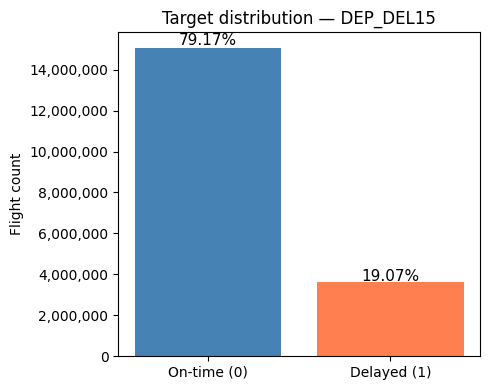

In [0]:
# Target distribution & class imbalance

target_counts = (
    df_train.groupBy(TARGET).count()
    .orderBy(TARGET).toPandas()
)
total = target_counts["count"].sum()
target_counts["pct"] = (target_counts["count"] / total * 100).round(2)
print("Target distribution:")
display(target_counts)

n_delayed = target_counts.loc[target_counts[TARGET].astype(float) == 1, "count"].values[0]
n_ontime  = target_counts.loc[target_counts[TARGET].astype(float) == 0, "count"].values[0]
print(f"\nClass imbalance — on-time : delayed = {n_ontime/n_delayed:.1f} : 1")
print(f"Baseline accuracy (predict all on-time): {n_ontime/total*100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
# Non null rows for plotting
plot_df = target_counts[target_counts[TARGET].astype(str).isin(["0.0", "1.0"])].reset_index(drop=True)
ax.bar(["On-time (0)", "Delayed (1)"], plot_df["count"], color=["steelblue", "coral"])
ax.set_ylabel("Flight count")
ax.set_title(f"Target distribution — {TARGET}")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, row in plot_df.iterrows():
    ax.text(i, row["count"] * 1.01, f"{row['pct']}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## Null rates on key columns

**Section summary:** The table and bar chart quantify missing values on the **train** split for the listed columns.

From the rendered table in the cell output:

- **`DEP_DEL15`:** **336,642** null rows (**1.77%**) — typically cancelled or diverted flights without a 15-minute delay label.
- **Core schedule / identity fields** (`CRS_DEP_TIME`, `DAY_OF_WEEK`, `MONTH`, `DISTANCE`, `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`): **0%** null in this run.

These null targets are dropped in **Cleaning** before modeling.

Null rates:


column,null_count,null_pct
DEP_DEL15,336642,1.77
CRS_DEP_TIME,0,0.0
DAY_OF_WEEK,0,0.0
MONTH,0,0.0
DISTANCE,0,0.0
OP_UNIQUE_CARRIER,0,0.0
ORIGIN,0,0.0
DEST,0,0.0


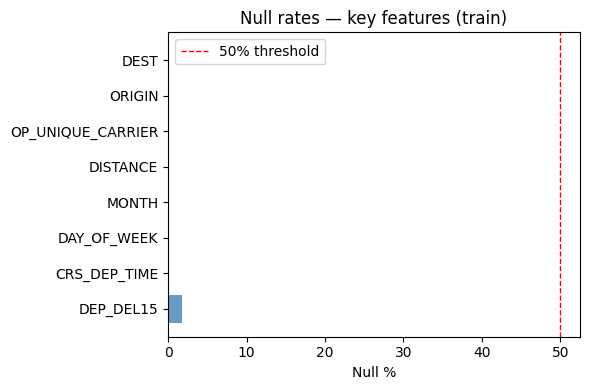

In [0]:
# Null rates for key features

key_cols = [c for c in [
    TARGET,
    "CRS_DEP_TIME", "DAY_OF_WEEK", "MONTH", "DISTANCE",
    "OP_UNIQUE_CARRIER", "ORIGIN", "DEST",
    "HourlyDryBulbTemperature", "HourlyWindSpeed", "HourlyVisibility",
    "HourlyRelativeHumidity", "HourlySeaLevelPressure",
    "HourlyPrecipitation", "HourlyWindDirection",
] if c in df_train.columns]

n_total = df_train.count()
null_expr = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in key_cols]
null_row   = df_train.agg(*null_expr).toPandas().T.reset_index()
null_row.columns = ["column", "null_count"]
null_row["null_pct"] = (null_row["null_count"] / n_total * 100).round(2)
null_row = null_row.sort_values("null_pct", ascending=False)

print("Null rates:")
display(null_row)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(null_row["column"], null_row["null_pct"], color="steelblue", alpha=0.8)
ax.set_xlabel("Null %"); ax.set_title("Null rates — key features (train)")
ax.axvline(x=50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.legend(); plt.tight_layout(); plt.show()

## Descriptive statistics (numeric features)

**Section summary:** Summary statistics on **train** for distance, elapsed time, and hourly weather-style numerics (see printed table in the cell output: `Descriptive statistics — numeric features (train):`). Use this to spot scale differences, heavy tails, or features that need imputation or scaling later.


In [0]:
# Numeric feature summary statistics

numeric_features = [c for c in [
    "DISTANCE", "CRS_ELAPSED_TIME",
    "HourlyDryBulbTemperature", "HourlyWindSpeed", "HourlyVisibility",
    "HourlyRelativeHumidity", "HourlySeaLevelPressure", "HourlyPrecipitation",
] if c in df_train.columns]

print("Descriptive statistics — numeric features (train):")
desc_pd = df_train.select(numeric_features).describe().toPandas() 

# Round to 3 decimal places
numeric_cols = desc_pd.columns[1:]  # skip the 'summary' column
desc_pd[numeric_cols] = desc_pd[numeric_cols].apply(pd.to_numeric, errors="coerce").round(3)
display(desc_pd)

Descriptive statistics — numeric features (train):


summary,DISTANCE
count,1.9035641E7
mean,824.95
stddev,607.85
min,21.0
max,5095.0


## Categorical cardinalities

**Section summary:** Counts distinct values per categorical column on **train** (printed table + bar chart). Watch for matplotlib `UserWarning` on tick labels; it does not affect the counts.

Example values from the latest run:

| Column | Approx. nunique |
|--------|-----------------|
| `ORIGIN` | 368 |
| `DEST` | 367 |
| `DAY_OF_MONTH` | 31 |
| `OP_UNIQUE_CARRIER` | 19 |
| `MONTH` | 8 |
| `DAY_OF_WEEK` | 7 |

Large airport cardinality motivates **target encoding** later instead of one-hot.

Categorical cardinalities:


column,cardinality
ORIGIN,368
DEST,367
DAY_OF_MONTH,31
OP_UNIQUE_CARRIER,19
MONTH,8
DAY_OF_WEEK,7


/root/.ipykernel/2051/command-8870818305337990-1475286500:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(card_df["column"], rotation=25, ha="right")


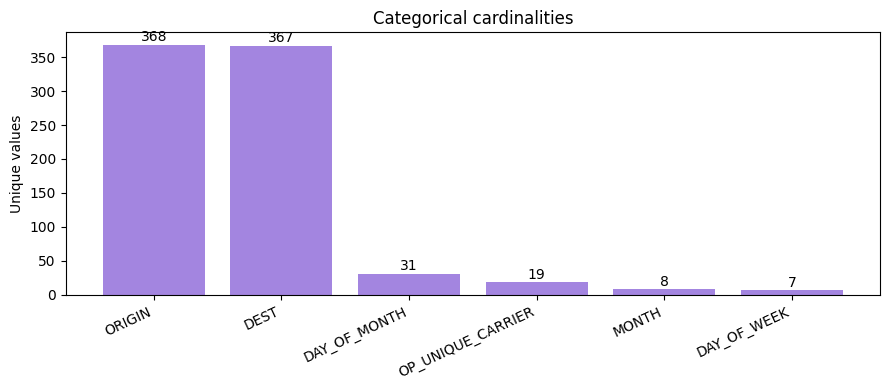

In [0]:
# Categorical cardinalities

cat_cols = [c for c in [
    "OP_UNIQUE_CARRIER", "ORIGIN", "DEST",
    "DAY_OF_WEEK", "MONTH", "DAY_OF_MONTH",
] if c in df_train.columns]

card_data = [(c, df_train.select(c).distinct().count()) for c in cat_cols]
card_df = pd.DataFrame(card_data, columns=["column", "cardinality"]).sort_values("cardinality", ascending=False)

print("Categorical cardinalities:")
display(card_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(card_df["column"], card_df["cardinality"], color="mediumpurple", alpha=0.85)
ax.set_ylabel("Unique values")
ax.set_title("Categorical cardinalities")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for i, (_, row) in enumerate(card_df.iterrows()):
    ax.text(i, row["cardinality"] + 5, str(row["cardinality"]), ha="center", fontsize=10)

ax.set_xticklabels(card_df["column"], rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Cleaning and train-only preprocessing EDA

**Section summary:** Rows with null `DEP_DEL15` are removed on all splits. **Train-only** data drives preprocessing (val and test never refit statistics).

- **Rolling median imputation:** We aggregate each numeric impute column to a **calendar-day** median on **train** only, then apply a **calendar lookback** (`ROLL_LOOKBACK_DAYS_IMPUTE`, 7 days) over that **small daily series** so a flight day uses only **prior** train days (no same-day or future leakage within train). **Validation and test** use the imputation row **frozen at the last train calendar date** (production-style scoring). Early train days with shorter history fall back to the same **global train median** per column used previously (see code).
- **Rolling z-score on weather:** For the six `avg_Hourly*` scalers, we compute **rolling mean** and **population std** on the **train daily** (post-imputation) series over `ROLL_LOOKBACK_DAYS_SCALE` (default 7), then **freeze** `(mu, sd)` from the last train date for val/test.
- **Metrics / F-beta:** Choosing static vs rolling or tuning window length with validation **F-beta** is intentionally left to **Phase 3.4** / the modeling notebook.

A warning may appear if `avg_feat_ceiling_hundreds_ft` is nearly all-null on train; that column uses a **sentinel** when the global median is undefined.

**Row counts after dropping null target (from cell output):**  
Train **18,698,999** | Val **6,329,538** | Test **6,241,008**

In [0]:
# Drop null target (cancelled/diverted flights)
df_train_clean = df_train.filter(F.col(TARGET).isNotNull()).cache()
df_val_clean   = df_val.filter(F.col(TARGET).isNotNull())
df_test_clean  = df_test.filter(F.col(TARGET).isNotNull())
n_tr, n_v, n_t = df_train_clean.count(), df_val_clean.count(), df_test_clean.count()
print(f"After drop-null: Train {n_tr:,} | Val {n_v:,} | Test {n_t:,}")

After drop-null: Train 18,698,999 | Val 6,329,538 | Test 6,241,008


In [0]:
df_train_clean.printSchema()

root
 |-- ORIGIN: string (nullable = true)
 |-- FL_DATE: string (nullable = true)
 |-- dep_2h_bin: long (nullable = true)
 |-- QUARTER: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- OP_UNIQUE_CARRIER: string (nullable = true)
 |-- OP_CARRIER_AIRLINE_ID: integer (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- TAIL_NUM: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN_AIRPORT_ID: integer (nullable = true)
 |-- ORIGIN_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- ORIGIN_CITY_MARKET_ID: integer (nullable = true)
 |-- ORIGIN_CITY_NAME: string (nullable = true)
 |-- ORIGIN_STATE_ABR: string (nullable = true)
 |-- ORIGIN_STATE_FIPS: integer (nullable = true)
 |-- ORIGIN_STATE_NM: string (nullable = true)
 |-- ORIGIN_WAC: integer (nullable = true)
 |-- DEST_AIRPORT_ID: integer (nullable = true)
 |-- DEST_AIRPORT_SEQ_ID: integer 

In [0]:
# Train-only null rates for numeric columns we impute in the next cell
_num_like = ("double", "int", "bigint", "float", "decimal")

def _cols_to_audit_train(df):
    dt = {f.name: str(f.dataType).lower() for f in df.schema.fields}
    out = []
    for c in df.columns:
        t = dt.get(c, "")
        if not any(t.startswith(x) for x in _num_like):
            continue
        if c.startswith("avg_Hourly") or c.startswith("avg_feat_"):
            out.append(c)
        elif c.startswith("last_WeatherType_"):
            out.append(c)
        elif c.startswith("last_feat_") and "_category" not in c:
            out.append(c)
        elif c.startswith("closest_station_") and c.endswith("_km"):
            out.append(c)
    return sorted(set(out))

_audit_cols = _cols_to_audit_train(df_train_clean)
_n_train = df_train_clean.count()
rows = []
for c in _audit_cols:
    nn = df_train_clean.filter(F.col(c).isNull() | F.isnan(F.col(c))).count()
    rows.append((c, nn, 100.0 * nn / max(_n_train, 1)))

eda_null = (
    pd.DataFrame(rows, columns=["column", "null_or_nan_ct", "pct"])
    .sort_values("pct", ascending=False)
)
print(f"Train rows (labeled): {_n_train:,}")
display(eda_null.head(50))

all_null = eda_null[eda_null["pct"] >= 99.999]["column"].tolist()
if all_null:
    print("\n[WARNING] Near/all-null on train (investigate upstream or check imputation):", all_null)

Train rows (labeled): 18,698,999


column,null_or_nan_ct,pct
avg_feat_ceiling_hundreds_ft,18698999,100.0
avg_HourlyWindGustSpeed,13875478,74.20438922960528
avg_HourlyWindDirection_Cos,1036720,5.544253999906626
avg_HourlyWindDirection_Sin,1036720,5.544253999906626
avg_HourlyPrecipitation,723097,3.867035877161125
avg_feat_pressure_change_magnitude,696808,3.72644546373846
avg_HourlyPressureChange,696808,3.72644546373846
avg_HourlyWindDirection,503173,2.6909087486447802
avg_HourlyRelativeHumidity,468424,2.5050752716763074
avg_feat_dew_point_spread,468424,2.5050752716763074



[WARNING] Near/all-null on train (investigate upstream or check imputation): ['avg_feat_ceiling_hundreds_ft']


In [0]:
# Rolling median imputation (train-only calendar lookback on daily aggregates).
# Val/test: frozen imputation from the last train calendar date (no refit).
ROLL_LOOKBACK_DAYS_IMPUTE = 7 

CEILING_COL = "avg_feat_https://dbc-fae72cab-cf59.cloud.databricks.com/editor/notebooks/1739535527638803?o=4021782157704243$0ceiling_hundreds_ft"
CEILING_SENTINEL = -1.0  # missing / not reported (hundreds of ft); document in writeup

WX_COLS = [c for c in df_train_clean.columns if c.startswith("avg_Hourly")]


def _extra_impute_cols(df):
    dt = {f.name: str(f.dataType).lower() for f in df.schema.fields}
    out = []
    for c in df.columns:
        t = dt.get(c, "")
        if not any(t.startswith(x) for x in _num_like):
            continue
        if c.startswith("avg_feat_") and "_category" not in c:
            out.append(c)
        elif c.startswith("last_WeatherType_"):
            out.append(c)
        elif c.startswith("last_feat_") and "_category" not in c:
            out.append(c)
        elif c.startswith("closest_station_") and c.endswith("_km"):
            out.append(c)
    return sorted(set(out))


EXTRA_IMPUTE_COLS = _extra_impute_cols(df_train_clean)
IMPUTE_COLS = sorted(set(WX_COLS + EXTRA_IMPUTE_COLS))

# Normalize precip strings before any percentile / daily aggregation
c_precip = "avg_HourlyPrecipitation"
if c_precip in df_train_clean.columns:
    def _fix_precip(dfx):
        return dfx.withColumn(
            c_precip,
            F.when(F.col(c_precip).cast("string") == "T", F.lit(0.0)).otherwise(
                F.col(c_precip).cast("double")
            ),
        )

    df_train_clean = _fix_precip(df_train_clean)
    df_val_clean = _fix_precip(df_val_clean)
    df_test_clean = _fix_precip(df_test_clean)

# Global train median per column (fallback for short history / NaNs — same rule as the old notebook)
static_medians = {}
for c in IMPUTE_COLS:
    m = df_train_clean.select(F.percentile_approx(c, 0.5).alias("m")).first()["m"]
    if m is None:
        m = CEILING_SENTINEL if c == CEILING_COL else 0.0
    static_medians[c] = float(m)

# One row per calendar day on train: daily median of each impute column
_agg_exprs = [F.percentile_approx(c, 0.5).alias(c) for c in IMPUTE_COLS]
train_daily = df_train_clean.groupBy("fl_date_d").agg(*_agg_exprs).orderBy("fl_date_d")

import pandas as pd

pdf_daily = train_daily.toPandas().sort_values("fl_date_d")
pdf_daily["fl_date_d"] = pd.to_datetime(pdf_daily["fl_date_d"])

_roll_cols = []
for c in IMPUTE_COLS:
    s = pd.to_numeric(pdf_daily[c], errors="coerce")
    # Lookback only: prior days in the daily series (shift removes same calendar day)
    rcol = f"_roll_impute_{c}"
    pdf_daily[rcol] = s.shift(1).rolling(ROLL_LOOKBACK_DAYS_IMPUTE, min_periods=1).median()
    pdf_daily[rcol] = pdf_daily[rcol].fillna(static_medians[c])
    _roll_cols.append(rcol)

_lookup_pdf = pdf_daily[["fl_date_d"] + _roll_cols].copy()
lookup_sdf = spark.createDataFrame(_lookup_pdf)
lookup_sdf = lookup_sdf.withColumn("fl_date_d", F.to_date("fl_date_d"))
_joined = lookup_sdf.select(
    "fl_date_d",
    *[F.col(f"_roll_impute_{c}").alias(f"_fill_{c}") for c in IMPUTE_COLS],
)
df_train_clean = df_train_clean.join(_joined, "fl_date_d", "left")
for c in IMPUTE_COLS:
    df_train_clean = df_train_clean.withColumn(
        c, F.coalesce(F.col(c), F.col(f"_fill_{c}"))
    ).drop(f"_fill_{c}")

train_max_date = df_train_clean.select(F.max("fl_date_d")).first()[0]
tm = pd.to_datetime(train_max_date)
_frozen_row = pdf_daily.loc[pdf_daily["fl_date_d"] == tm]
if _frozen_row.empty:
    _frozen_row = pdf_daily.iloc[[-1]]
frozen_impute = {
    c: float(_frozen_row[f"_roll_impute_{c}"].iloc[0]) for c in IMPUTE_COLS
}


def _apply_frozen_impute(dfx):
    out = dfx
    for c, fv in frozen_impute.items():
        out = out.withColumn(c, F.coalesce(F.col(c), F.lit(fv)))
    return out


df_train_clean = df_train_clean.cache()
df_val_clean = _apply_frozen_impute(df_val_clean)
df_test_clean = _apply_frozen_impute(df_test_clean)

print(
    f"Rolling median imputation ({ROLL_LOOKBACK_DAYS_IMPUTE}d lookback on train daily) "
    f"for {len(IMPUTE_COLS)} cols (avg_Hourly={len(WX_COLS)}, extra_engineered={len(EXTRA_IMPUTE_COLS)}). "
    f"Val/test frozen to train_end={train_max_date}. "
    f"{CEILING_COL}: sentinel {CEILING_SENTINEL} when global train median undefined."
)

Rolling median imputation (7d lookback on train daily) for 47 cols (avg_Hourly=15, extra_engineered=32). Val/test frozen to train_end=2019-08-06. avg_feat_https://dbc-fae72cab-cf59.cloud.databricks.com/editor/notebooks/1739535527638803?o=4021782157704243$0ceiling_hundreds_ft: sentinel -1.0 when global train median undefined.


In [0]:
# Rolling median + MAD on train daily series (causal shift(1)); val/test frozen at last train date.
# Same spirit as rolling median imputation (ROLL_LOOKBACK_DAYS_SCALE parallel to ROLL_LOOKBACK_DAYS_IMPUTE).
ROLL_LOOKBACK_DAYS_SCALE = 7
_WX_MAD_EPS = 1e-12

WX_COLS = [c for c in df_train_clean.columns if c.startswith("avg_Hourly")]

WX_SIX = [
    "avg_HourlyDryBulbTemperature",
    "avg_HourlyWindSpeed",
    "avg_HourlyRelativeHumidity",
    "avg_HourlySeaLevelPressure",
    "avg_HourlyVisibility",
    "avg_HourlyPrecipitation",
]
WX_SIX = [c for c in WX_SIX if c in WX_COLS]

DEW_COL = "avg_HourlyDewPointTemperature"
SCALE_COLS = list(WX_SIX)
if DEW_COL in df_train_clean.columns and DEW_COL not in SCALE_COLS:
    SCALE_COLS.append(DEW_COL)

c_precip = "avg_HourlyPrecipitation"
if c_precip in df_train_clean.columns:
    def _fix_precip(dfx):
        return dfx.withColumn(
            c_precip,
            F.when(F.col(c_precip).cast("string") == "T", F.lit(0.0)).otherwise(
                F.col(c_precip).cast("double")
            ),
        )
    df_train_clean = _fix_precip(df_train_clean)
    df_val_clean = _fix_precip(df_val_clean)
    df_test_clean = _fix_precip(df_test_clean)


def _mad1d(a):
    if a.size == 0:
        return np.nan
    m = np.median(a)
    return float(np.median(np.abs(a - m)))


static_med = {}
static_mad = {}
for c in SCALE_COLS:
    r = df_train_clean.select(
        F.percentile_approx(c, 0.5).alias("med"),
        F.stddev_pop(c).alias("sd"),
    ).first()
    static_med[c] = float(r["med"]) if r["med"] is not None else 0.0
    sdv = float(r["sd"]) if r["sd"] is not None else 0.0
    static_mad[c] = max(sdv * 0.6745, 1.0) if sdv > 1e-12 else 1.0

_agg_d = [F.percentile_approx(c, 0.5).alias(c) for c in SCALE_COLS]
train_daily_wx = df_train_clean.groupBy("fl_date_d").agg(*_agg_d).orderBy("fl_date_d")
pdf_wx = train_daily_wx.toPandas().sort_values("fl_date_d")
pdf_wx["fl_date_d"] = pd.to_datetime(pdf_wx["fl_date_d"])

_roll_med_cols = []
_roll_mad_cols = []
for c in SCALE_COLS:
    s = pd.to_numeric(pdf_wx[c], errors="coerce")
    rmed = s.shift(1).rolling(ROLL_LOOKBACK_DAYS_SCALE, min_periods=1).median()
    rmad = s.shift(1).rolling(ROLL_LOOKBACK_DAYS_SCALE, min_periods=1).apply(
        _mad1d, raw=True
    )
    cm = f"_wmed_{c}"
    ca = f"_wmad_{c}"
    pdf_wx[cm] = rmed.fillna(static_med[c])
    pdf_wx[ca] = rmad.fillna(static_mad[c]).clip(lower=_WX_MAD_EPS)
    _roll_med_cols.append(cm)
    _roll_mad_cols.append(ca)

_lk = pdf_wx[["fl_date_d"] + _roll_med_cols + _roll_mad_cols].copy()
lookup_wx = spark.createDataFrame(_lk)
lookup_wx = lookup_wx.withColumn("fl_date_d", F.to_date("fl_date_d"))

df_train_clean = df_train_clean.join(lookup_wx, "fl_date_d", "left")
for c in WX_SIX:
    cm, ca = f"_wmed_{c}", f"_wmad_{c}"
    df_train_clean = df_train_clean.withColumn(
        f"{c}_scl",
        (F.col(c).cast("double") - F.col(cm)) / F.col(ca),
    ).drop(cm, ca)

if DEW_COL in SCALE_COLS:
    cm, ca = f"_wmed_{DEW_COL}", f"_wmad_{DEW_COL}"
    df_train_clean = df_train_clean.withColumn(
        "wx_dewpoint_daily_anom",
        (F.col(DEW_COL).cast("double") - F.col(cm)) / F.col(ca),
    ).drop(cm, ca)

train_max_date_wx = df_train_clean.select(F.max("fl_date_d")).first()[0]
tm_wx = pd.to_datetime(train_max_date_wx)
_fr_wx = pdf_wx.loc[pdf_wx["fl_date_d"] == tm_wx]
if _fr_wx.empty:
    _fr_wx = pdf_wx.iloc[[-1]]
frozen_wx_med = {c: float(_fr_wx[f"_wmed_{c}"].iloc[0]) for c in SCALE_COLS}
frozen_wx_mad = {
    c: float(max(_fr_wx[f"_wmad_{c}"].iloc[0], _WX_MAD_EPS)) for c in SCALE_COLS
}


def _apply_frozen_wx_scl(dfx):
    out = dfx
    for c in WX_SIX:
        mu, sig = frozen_wx_med[c], frozen_wx_mad[c]
        out = out.withColumn(
            f"{c}_scl",
            (F.col(c).cast("double") - F.lit(mu)) / F.lit(sig),
        )
    if DEW_COL in SCALE_COLS and DEW_COL in out.columns:
        mu, sig = frozen_wx_med[DEW_COL], frozen_wx_mad[DEW_COL]
        out = out.withColumn(
            "wx_dewpoint_daily_anom",
            (F.col(DEW_COL).cast("double") - F.lit(mu)) / F.lit(sig),
        )
    return out


df_train_clean = df_train_clean.cache()
df_val_clean = _apply_frozen_wx_scl(df_val_clean)
df_test_clean = _apply_frozen_wx_scl(df_test_clean)

print(
    f"Weather *_scl (train rolling median+MAD, {ROLL_LOOKBACK_DAYS_SCALE}d lookback) for: {WX_SIX}. "
    f"Val/test frozen med/MAD at train_end={train_max_date_wx}."
)
if DEW_COL in SCALE_COLS:
    print("Extra: wx_dewpoint_daily_anom (same rolling stats as dewpoint channel).")

Weather *_scl (train rolling median+MAD, 7d lookback) for: ['avg_HourlyDryBulbTemperature', 'avg_HourlyWindSpeed', 'avg_HourlyRelativeHumidity', 'avg_HourlySeaLevelPressure', 'avg_HourlyVisibility', 'avg_HourlyPrecipitation']. Val/test frozen med/MAD at train_end=2019-08-06.
Extra: wx_dewpoint_daily_anom (same rolling stats as dewpoint channel).


**Section summary:** We compute Pearson correlations on **train** only: a bar chart of correlations for a curated numeric set, a heatmap on a subsample, and delay rates by carrier / day-of-week / hour. A later cell also ranks **all assembled numeric candidates** (0.5% sample) for feature-selection hints—those rankings include target-encoded rates and engineered fields, so the top line items may differ from the smaller first-pass `NUM_COLS` plot.

## Feature-to-target Pearson correlation

Correlations below use the fixed `NUM_COLS` list **before** target encoding. 

- **Time and schedule:** `dep_hour`, `CRS_DEP_TIME`, and peak flags show measurable linear association with delay in this view.
- **Weather:** hourly averages have **smaller but non-zero** correlation with `DEP_DEL15`; still useful after scaling and binning.
- **Distance:** weak linear relationship with delay here.
- **Multicollinearity:** several `avg_Hourly*` variables correlate strongly with each other (visible in the heatmap); that is expected for weather fields and motivates keeping both scaled and binned variants deliberately.

Pearson correlation with DEP_DEL15 (train only):


feature,corr
avg_HourlyVisibility,-0.03920463997548471
avg_HourlyRelativeHumidity,-0.02505401569139309
avg_HourlyWindDirection_Sin,-0.01031980945282881
avg_HourlyWindDirection_Cos,-0.005186565779877543
avg_HourlyAltimeterSetting,4.6364704695730743E-4
avg_HourlySeaLevelPressure,0.0025246037292431193
avg_HourlyStationPressure,0.0036647090668871793
DISTANCE,0.018479974210324678
avg_HourlyWindGustSpeed,0.026293640819959354
avg_HourlyWindDirection,0.030054797722812544


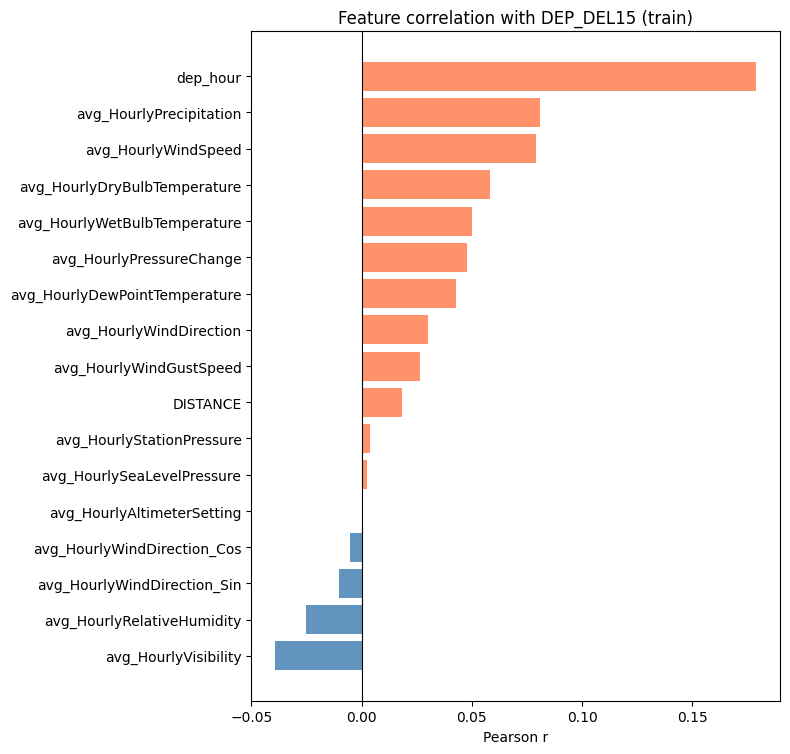

In [0]:
# All numeric features available after cleaning
NUM_COLS = [c for c in ["DISTANCE", "CRS_ELAPSED_TIME", "dep_hour"] + WX_COLS
            if c in df_train_clean.columns]

# Assemble features + target into a single vector; skip rows with remaining nulls
assembler = VectorAssembler(
    inputCols=NUM_COLS + [TARGET],
    outputCol="_vec",
    handleInvalid="skip",
)
vec_df = assembler.transform(df_train_clean.select(NUM_COLS + [TARGET]))

# Single Spark action → full Pearson matrix
corr_matrix = Correlation.corr(vec_df, "_vec", method="pearson").head()[0].toArray()

# Extract the last column (TARGET index = len(NUM_COLS))
target_idx = len(NUM_COLS)
corr_with_target = [
    (NUM_COLS[i], float(corr_matrix[i, target_idx]))
    for i in range(len(NUM_COLS))
]
corr_pd = pd.DataFrame(corr_with_target, columns=["feature", "corr"]).sort_values("corr")

print(f"Pearson correlation with {TARGET} (train only):")
display(corr_pd)

fig, ax = plt.subplots(figsize=(8, max(4, len(corr_pd) * 0.45)))
colors = ["coral" if v > 0 else "steelblue" for v in corr_pd["corr"]]
ax.barh(corr_pd["feature"], corr_pd["corr"], color=colors, alpha=0.85)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r")
ax.set_title(f"Feature correlation with {TARGET} (train)")
plt.tight_layout(); plt.show()

## Calendar & Holiday

In [0]:
# Chi-square / Cramér's V: calendar + holiday flags (train only; tiny aggregates in Spark)
from pyspark.sql import functions as F
from scipy.stats import chi2_contingency
import numpy as np

def chi2_binary_vs_cat(df, col):
    wide = (
        df.groupBy(col)
        .agg(
            F.sum((F.col(TARGET) == 0).cast("int")).alias("y0"),
            F.sum((F.col(TARGET) == 1).cast("int")).alias("y1"),
        )
        .orderBy(col)
        .toPandas()
    )
    tab = wide.set_index(col)[["y0", "y1"]].values
    # skip if only one level (chi2 not defined meaningfully)
    if tab.shape[0] < 2:
        print(f"{col}: only one category present — skip chi-square")
        return
    chi2, p, dof, _ = chi2_contingency(tab)
    n = tab.sum()
    v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
    print(f"{col}: chi2={chi2:.2f}, p={p:.4g}, Cramér's V={v:.3f}")

CALENDAR_COLS = ["MONTH", "DAY_OF_WEEK"]
HOLIDAY_COLS = [
    "is_holiday",
    "is_pre_holiday",
    "is_post_holiday",
    "is_holiday_weekend_adjacent",
]

for c in CALENDAR_COLS + HOLIDAY_COLS:
    if c not in df_train_clean.columns:
        print(f"{c}: not in df_train_clean — skip")
        continue
    chi2_binary_vs_cat(df_train_clean, c)

MONTH: chi2=50373.68, p=0, Cramér's V=0.052
DAY_OF_WEEK: chi2=19772.52, p=0, Cramér's V=0.033
is_holiday: chi2=264.09, p=2.207e-59, Cramér's V=0.004
is_pre_holiday: chi2=230.00, p=5.952e-52, Cramér's V=0.004
is_post_holiday: chi2=6260.34, p=0, Cramér's V=0.018
is_holiday_weekend_adjacent: chi2=675.46, p=6.489e-149, Cramér's V=0.006


All the above Cramér’s V values are well below 0.10, which is the usual “small” ballpark for (V) in many guides. So these are real but weak marginal links to DEP_DEL15, not strong stand-alone drivers.

## Correlation heatmap (subsample)

**Section summary:** Pairwise Pearson correlations for the same numeric feature family on a random **train** subsample (~0.5%). Use this to spot redundant weather columns; it complements (not replaces) the later full-candidate correlation table.

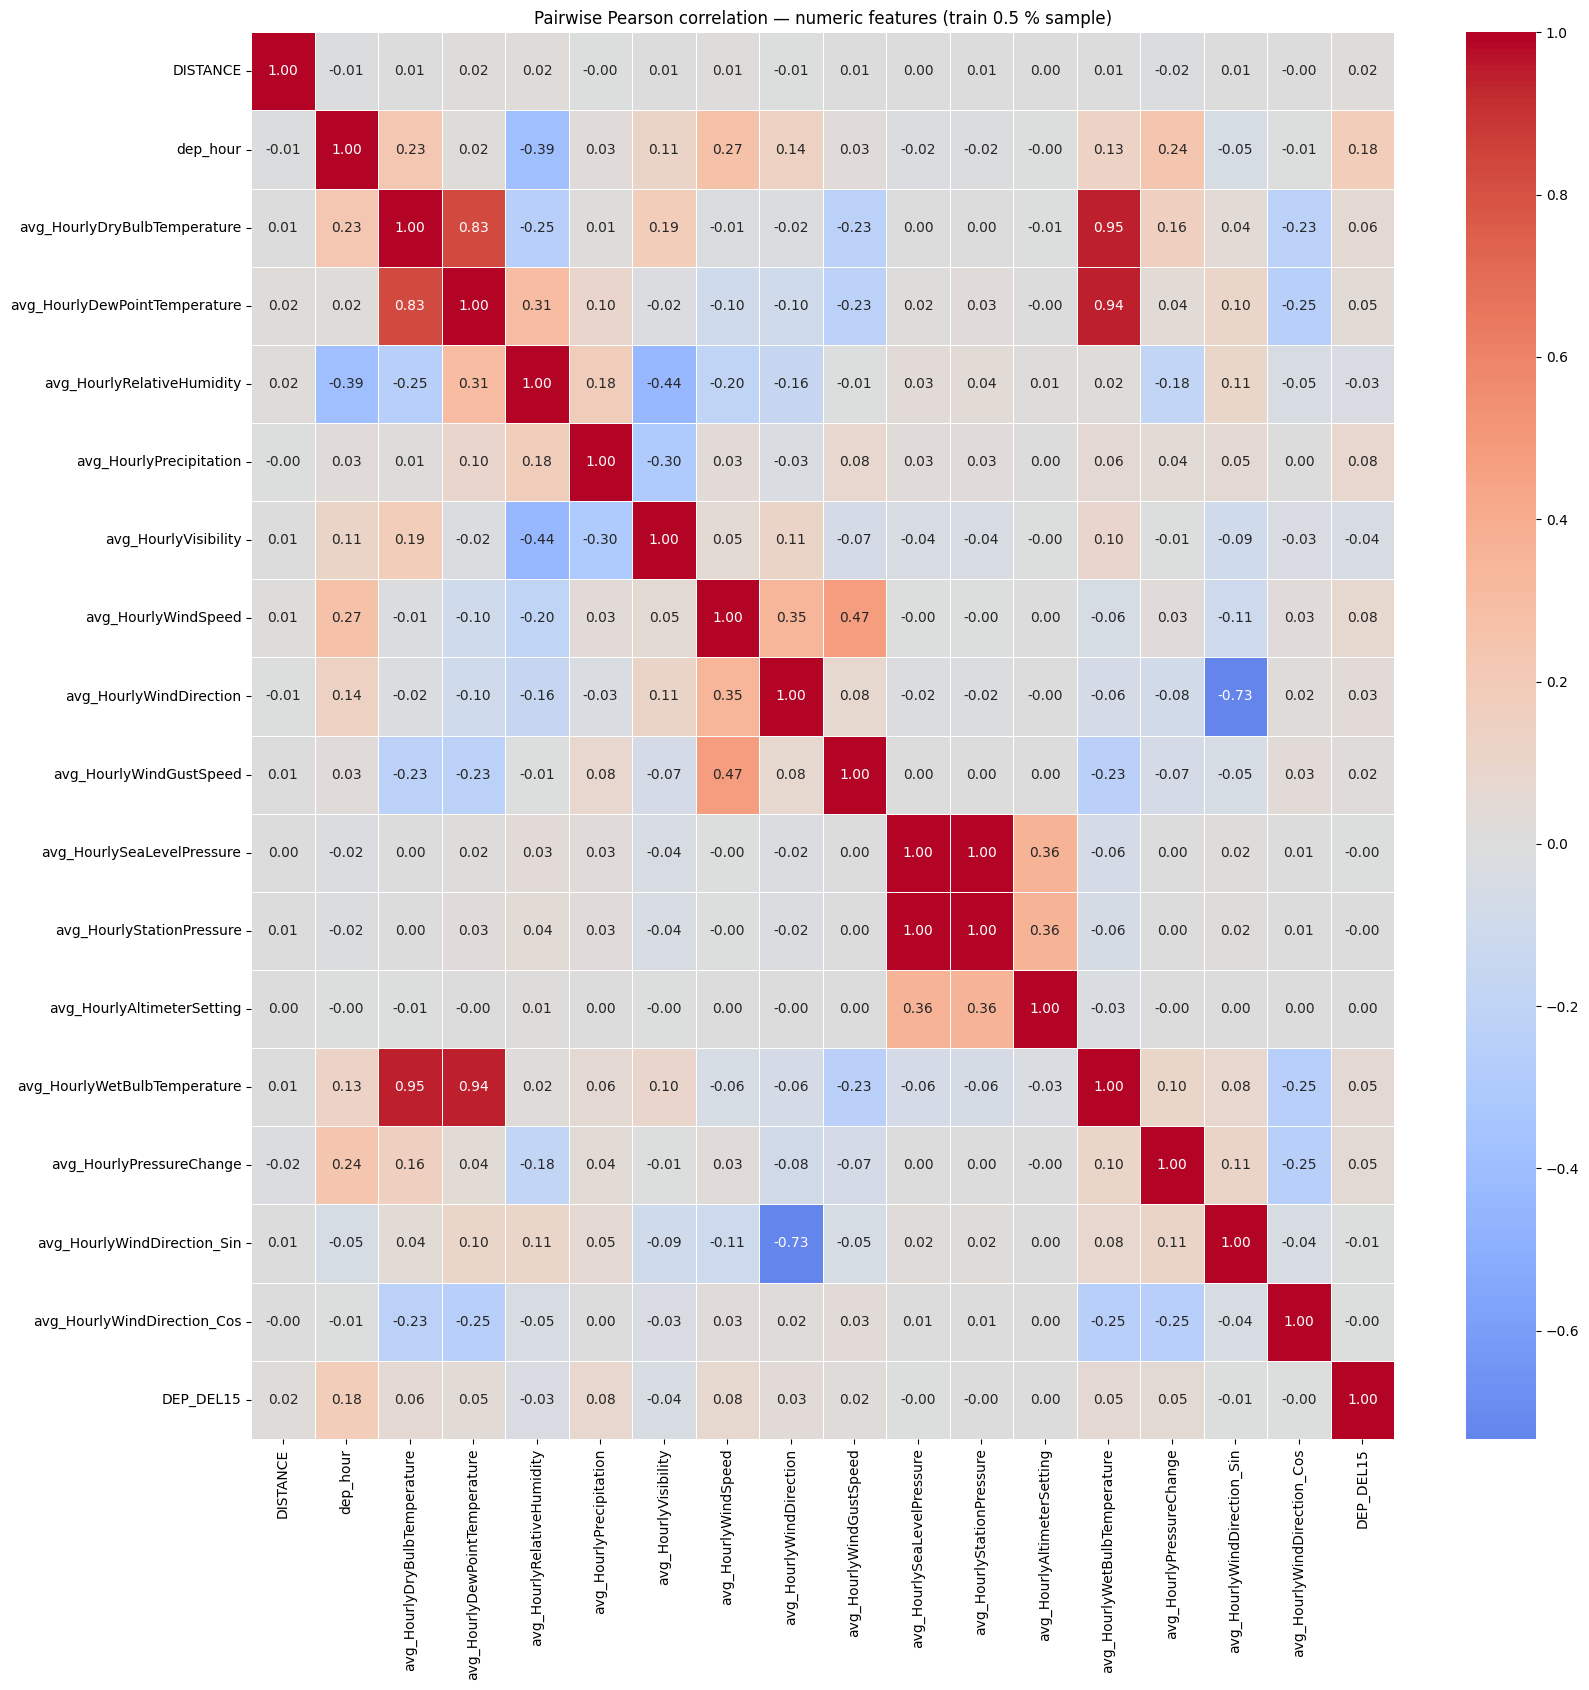

In [0]:
# Sample ~0.5 % ≈ 95 K rows; sufficient for a stable correlation estimate
sample_pd = (
    df_train_clean
    .select(NUM_COLS + [TARGET])
    .sample(fraction=0.005, seed=42)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(max(8, len(NUM_COLS)), max(6, len(NUM_COLS))))
sns.heatmap(
    sample_pd.corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Pairwise Pearson correlation — numeric features (train 0.5 % sample)")
plt.tight_layout(); plt.show()

## Delay rate by categorical features

**Section summary:** Bar charts show the **empirical delay rate** (mean of `DEP_DEL15`) on **train** for carrier, day of week, and departure hour.

Read the plots directly for this run (rates vary by year and slice). In general, delay rates differ by **airline**, **weekday**, and **hour of day**—supporting time-based and carrier/route features and motivating target encoding.

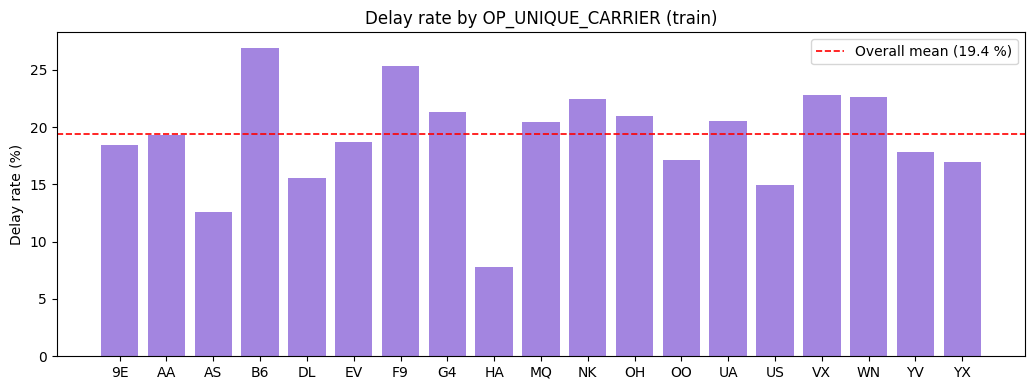

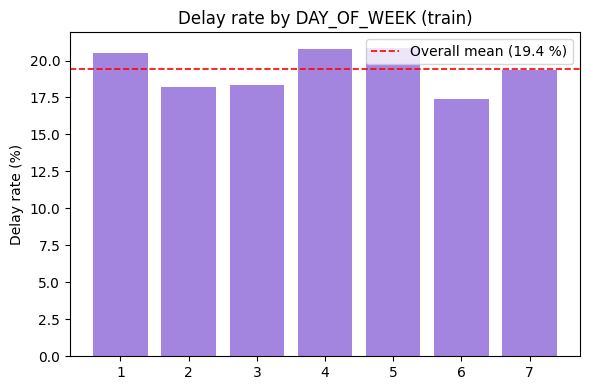

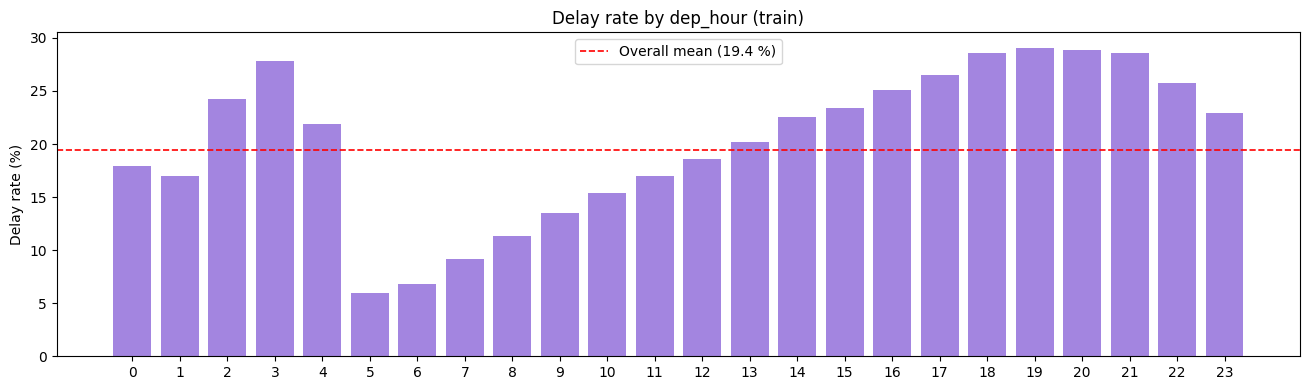

In [0]:
overall_delay_rate = df_train_clean.select(F.mean(TARGET)).first()[0]
for grp_col in ["OP_UNIQUE_CARRIER", "DAY_OF_WEEK", "dep_hour"]:
    if grp_col not in df_train_clean.columns:
        continue
    rate_pd = (
        df_train_clean
        .groupBy(grp_col)
        .agg(F.mean(TARGET).alias("delay_rate"), F.count("*").alias("n"))
        .orderBy(grp_col)
        .toPandas()
    )
    fig, ax = plt.subplots(figsize=(max(6, len(rate_pd) * 0.55), 4))
    ax.bar(rate_pd[grp_col].astype(str), rate_pd["delay_rate"] * 100,
           color="mediumpurple", alpha=0.85)
    ax.axhline(y=overall_delay_rate * 100, color="red", linestyle="--",
               linewidth=1.2, label=f"Overall mean ({overall_delay_rate*100:.1f} %)")
    ax.set_ylabel("Delay rate (%)"); ax.set_title(f"Delay rate by {grp_col} (train)")
    ax.legend(); plt.tight_layout(); plt.show()

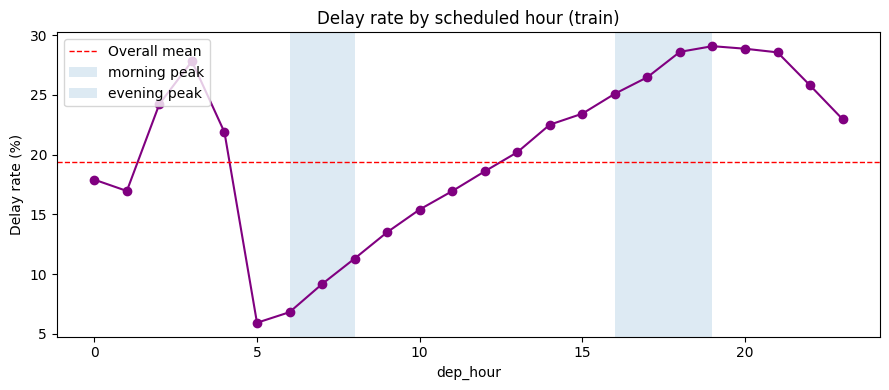

In [0]:
rate_pd = (
    df_train_clean.groupBy("dep_hour")
    .agg(F.mean(TARGET).cast("double").alias("delay_rate"))
    .orderBy("dep_hour")
    .toPandas()
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rate_pd["dep_hour"], rate_pd["delay_rate"] * 100, marker="o", color="purple")
ax.axhline(float(df_train_clean.select(F.mean(TARGET).cast("double")).first()[0]) * 100,
            color="red", linestyle="--", linewidth=1, label="Overall mean")
for lo, hi, lab in [(6, 8, "morning peak"), (16, 19, "evening peak")]:
    ax.axvspan(lo, hi, alpha=0.15, label=lab)
ax.set_xlabel("dep_hour"); ax.set_ylabel("Delay rate (%)")
ax.set_title("Delay rate by scheduled hour (train)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## Congestion features

decile,delay_rate,mean_origin_sched_count_prev2h,n
1,0.1398507941601155,0.8171249799454516,1869900
2,0.15799026685919032,4.633673993261672,1869900
3,0.16903898604203432,10.78183164875127,1869900
4,0.19114818974276698,18.233565431306488,1869900
5,0.19982245039841703,26.432005454837157,1869900
6,0.20889780202149846,35.96229851863736,1869900
7,0.2157553879886625,45.67459382854698,1869900
8,0.21008075298144285,57.072683565966095,1869900
9,0.2194603989518156,77.97627841061019,1869900
10,0.2287920363613222,123.64194483231448,1869899


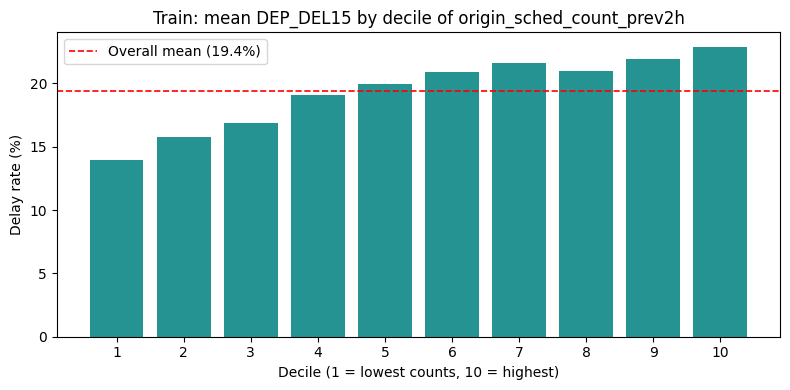

decile,delay_rate,mean_origin_2h_sched_departures,n
1,0.1593999679127226,2.0724846248462483,1869900
2,0.1679437403069683,6.440388256056473,1869900
3,0.18177710037969944,13.297464570297876,1869900
4,0.20409647574736617,21.491377613776137,1869900
5,0.2036060751911867,30.41675704583133,1869900
6,0.20485854858548586,40.05686025990695,1869900
7,0.20138617038344298,49.35717952831702,1869900
8,0.19202470720359377,59.80343708219691,1869900
9,0.21241724156372,79.59564629124552,1869900
10,0.21332702996258088,125.68027631438918,1869899


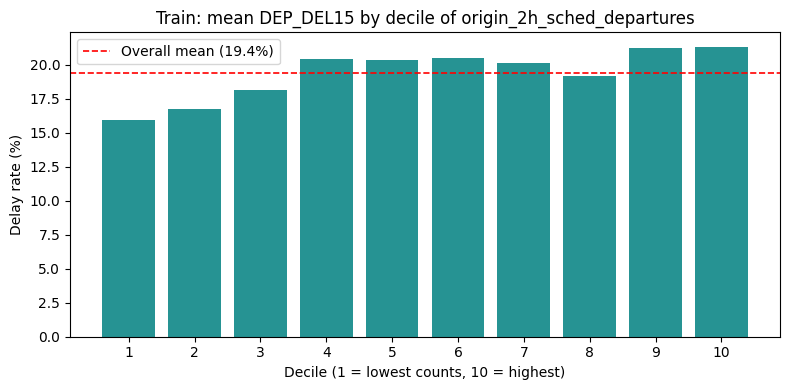

In [0]:
from pyspark.sql.window import Window

overall_delay_rate = float(
    df_train_clean.agg(F.mean(F.col(TARGET).cast("double"))).collect()[0][0]
)

for congestion_col in ["origin_sched_count_prev2h", "origin_2h_sched_departures"]:
    if congestion_col not in df_train_clean.columns:
        print(f"skip {congestion_col}: not in df_train_clean.columns")
        continue

    w = Window.orderBy(F.asc(congestion_col))

    dec_pd = (
        df_train_clean.select(F.col(congestion_col), F.col(TARGET).cast("double").alias(TARGET))
        .withColumn("decile", F.ntile(10).over(w))
        .groupBy("decile")
        .agg(
            F.avg(TARGET).alias("delay_rate"),
            F.avg(F.col(congestion_col)).alias(f"mean_{congestion_col}"),
            F.count(F.lit(1)).alias("n"),
        )
        .orderBy("decile")
        .toPandas()
    )

    display(dec_pd)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(dec_pd["decile"].astype(str), dec_pd["delay_rate"] * 100.0, color="teal", alpha=0.85)
    ax.axhline(
        y=overall_delay_rate * 100.0,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"Overall mean ({overall_delay_rate * 100:.1f}%)",
    )
    ax.set_xlabel("Decile (1 = lowest counts, 10 = highest)")
    ax.set_ylabel("Delay rate (%)")
    ax.set_title(f"Train: mean {TARGET} by decile of {congestion_col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Takeaways

**Full candidate set (post–feature-engineering sample):** The later `VectorAssembler` + `Correlation` cell sorts **all numeric candidates** on a **0.5%** sample of labeled train. In the saved run, the largest absolute Pearson correlations with `DEP_DEL15` at the top of the printed table included:

- **`hour_delay_rate`** ≈ **0.190**
- **`dep_hour_sin`** ≈ **−0.186**
- **`CRS_DEP_TIME`** ≈ **0.184**
- **`dep_hour`** ≈ **0.183**
- **`route_delay_rate`** ≈ **0.136**
- **`is_morning_peak`** ≈ **−0.133**
- **`wx_morning_peak_x_vis_scl`** ≈ **−0.132**
- **`evening_peak_x_route_delay`** ≈ **0.132**
- **`morning_peak_x_origin_delay`** ≈ **−0.128**
- Further rows in that table include **`od_distinct_x_hour_delay`**, **`carrier_x_origin_delay`**, and weather cross-terms (e.g. **`wx_temp_scl_x_wind_scl`**, **`precip_bin_x_temp_scl`**) before raw **`is_evening_peak`** / **`precip_bin`** univariate lines.

**Time of day (train delay rate by `dep_hour`):** The marginal delay rate is **strongly nonlinear** across the clock: a **high early-morning spike** (e.g. around hour 3), a **sharp trough near dawn** (about **5–6%** near hour 5), then a **long climb** through midday until the rate crosses the **overall mean (~19–20%)** in the early afternoon. **Evening hours (roughly 16–19)** sit **well above** the overall mean (**~25–29%**), while the shaded **morning peak (6–8)** sits on the **low, rising** part of the curve—consistent with **`is_morning_peak`** being **negatively** associated with delay in linear summaries and **`is_evening_peak`** **positively** associated. Together with strong **`dep_hour` / `CRS_DEP_TIME`** and **`dep_hour_sin` / `dep_hour_cos` / `hour_delay_rate`**, this supports keeping **raw clock features plus sinusoidal and target-encoded hour** rather than treating time as a simple straight-line trend.

**Weather:** `precip_bin` and scaled hourly fields rank below time/route encodings in linear Pearson terms but still contribute; the notebook adds **interactions** below to expose nonlinear effects.

**Distance:** remains a weak linear predictor in these views.

**Multicollinearity:** strong correlations among raw hourly weather columns persist; scaled (`*_scl`), binned, and interaction features spread signal across more stable inputs.

**Congestion features** show a clear gradient in delay rate across deciles, so we retain the count variables and the busy flag derived from **`origin_sched_count_prev2h`**.

**Extended interaction blocks (A–E):** After those columns are engineered, see **EDA — extended interaction features (train)** for train-only null rates, descriptive stats, and linear correlation hints vs. `DEP_DEL15` (prune or keep features based on that table and modeling).

# Feature engineering 

**Section summary:** By this point, **holiday flags** and **schedule-based congestion** columns already live on `df_*_clean` from the leakage-drop cell. This section adds **temporal/route numerics**, **target encodings**, **weather bins & interactions**, and **static airport statistics** (hub flags, departure counts, route diversity). Everything is applied consistently to train, validation, and test.

| Block | What we get |
|-------|----------------|
| Already upstream | `is_holiday`, `is_pre_holiday`, `is_post_holiday`, `is_holiday_weekend_adjacent`; `origin_2h_sched_departures`, `origin_sched_count_prev2h`, `is_origin_busy_2h_before` |
| Temporal | Weekend / late-night flags; sin–cos hour, DOW, month, quarter; coarse `dep_time_blk` |
| Target encoding | `carrier_delay_rate`, `origin_delay_rate`, `dest_delay_rate`, `route_delay_rate`, `hour_delay_rate` (train statistics only, broadcast to val/test) |
| Weather | Integer `precip_bin`, `wind_bin`, `vis_bin`; five `wx_*` interaction columns using scaled hourly fields + bins |
| Airport static | `origin_train_departures`, `dest_train_departures`, `is_hub_origin`, `is_hub_dest`, `origin_dest_distinct_count` |
| **A–E (extended)** | Curated products of schedule / network / weather / bins (see **Adding more features**): holiday×rates, hub×congestion, peak×route, weather×bins, residuals, `temp_anomaly_station_month`, `severe_wx_index`, `prev2h_busy×wx`, etc. |

Subsections below describe each block in more detail.


## Temporal and route features

**Section summary:** Adds calendar and clock structure beyond raw `CRS_DEP_TIME`: weekend / late-night indicators, sinusoidal encodings for hour, DOW, month, and quarter, and `dep_time_blk` buckets. Applied to `df_train_fe`, `df_val_fe`, `df_test_fe` after cleaning.


In [0]:
def add_temporal_features(df):
    df = df.withColumn("is_weekend",
        F.when(F.col("DAY_OF_WEEK").isin(6, 7), 1).otherwise(0))
    df = df.withColumn("is_late_night",
        F.when(F.col("dep_hour").isin(*range(22, 24), *range(0, 6)), 1).otherwise(0))
    df = df.withColumn("dep_hour_sin", F.sin(2 * np.pi * F.col("dep_hour") / 24))
    df = df.withColumn("dep_hour_cos", F.cos(2 * np.pi * F.col("dep_hour") / 24))
    df = df.withColumn("dep_hour_sin2", F.sin(4 * np.pi * F.col("dep_hour") / 24))
    df = df.withColumn("dep_hour_cos2", F.cos(4 * np.pi * F.col("dep_hour") / 24))
    df = df.withColumn("day_sin", F.sin(2 * np.pi * F.col("DAY_OF_WEEK") / 7))
    df = df.withColumn("day_cos", F.cos(2 * np.pi * F.col("DAY_OF_WEEK") / 7))
    df = df.withColumn(
        "dep_time_blk",
        F.when((F.col("dep_hour") >= 0) & (F.col("dep_hour") < 5), "blk_00_04")
        .when((F.col("dep_hour") >= 5) & (F.col("dep_hour") < 12), "blk_05_11")
        .when((F.col("dep_hour") >= 12) & (F.col("dep_hour") < 17), "blk_12_16")
        .when((F.col("dep_hour") >= 17) & (F.col("dep_hour") < 21), "blk_17_20")
        .otherwise("blk_21_23"),
    )
    df = df.withColumn("month_sin", F.sin(2 * np.pi * F.col("MONTH").cast("double") / 12))
    df = df.withColumn("month_cos", F.cos(2 * np.pi * F.col("MONTH").cast("double") / 12))
    q = (
        F.col("QUARTER").cast("double")
        if "QUARTER" in df.columns
        else F.floor((F.col("MONTH").cast("double") - F.lit(1.0)) / F.lit(3.0)) + F.lit(1.0)
    )
    df = df.withColumn("quarter_sin", F.sin(2 * np.pi * q / 4))
    df = df.withColumn("quarter_cos", F.cos(2 * np.pi * q / 4))
    return df

df_train_fe = add_temporal_features(df_train_clean)
df_val_fe   = add_temporal_features(df_val_clean)
df_test_fe  = add_temporal_features(df_test_clean)

## Target encoding

**Section summary:** For `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, `ROUTE`, and `dep_hour`, replace raw categoricals with the **train-split mean** of `DEP_DEL15` (`*_delay_rate` columns). Val/test rows use the same train table (missing groups filled with the global train mean). **target encoding** keeps a **single numeric signal** per high-cardinality grouping.


In [0]:
global_mean = df_train_clean.select(F.mean(TARGET)).first()[0]

def make_target_enc(df, group_col, new_col):
    return df.groupBy(group_col).agg(F.mean(TARGET).alias(new_col))

carrier_enc = make_target_enc(df_train_clean, "OP_UNIQUE_CARRIER", "carrier_delay_rate")
origin_enc  = make_target_enc(df_train_clean, "ORIGIN",            "origin_delay_rate")
dest_enc    = make_target_enc(df_train_clean, "DEST",              "dest_delay_rate")
route_enc   = make_target_enc(df_train_clean, "ROUTE",             "route_delay_rate")
hour_enc    = make_target_enc(df_train_clean, "dep_hour",          "hour_delay_rate")

def apply_enc(df, enc_df, key_col, new_col, fill_val):
    return df.join(enc_df, on=key_col, how="left").fillna(fill_val, subset=[new_col])

for split_name, split_df in [("train", df_train_fe), ("val", df_val_fe), ("test", df_test_fe)]:
    split_df = apply_enc(split_df, carrier_enc, "OP_UNIQUE_CARRIER", "carrier_delay_rate", global_mean)
    split_df = apply_enc(split_df, origin_enc,  "ORIGIN",            "origin_delay_rate",  global_mean)
    split_df = apply_enc(split_df, dest_enc,    "DEST",              "dest_delay_rate",    global_mean)
    split_df = apply_enc(split_df, route_enc,   "ROUTE",             "route_delay_rate",   global_mean)
    split_df = apply_enc(split_df, hour_enc,    "dep_hour",          "hour_delay_rate",    global_mean)
    if split_name == "train": df_train_fe = split_df
    elif split_name == "val": df_val_fe   = split_df
    else:                     df_test_fe  = split_df

# ── 7-day rolling route delay rate ────────────────────────────────────────────
_route_daily = (
    df_train_fe
    .filter(F.col(TARGET).isNotNull())
    .withColumn("fl_date_int", F.col("_sort_date").cast("long"))
    .groupBy("ROUTE", "fl_date_int")
    .agg(F.mean(TARGET).alias("_daily_rate"), F.count(F.lit(1)).alias("_daily_cnt"))
)
_route_daily_a = _route_daily.alias("a")
_route_daily_b = _route_daily.alias("b")
_route_7d = (
    _route_daily_a.join(
        _route_daily_b,
        on=(
            (F.col("a.ROUTE") == F.col("b.ROUTE")) &
            (F.col("b.fl_date_int") >= F.col("a.fl_date_int") - 7) &
            (F.col("b.fl_date_int") <  F.col("a.fl_date_int"))
        ),
        how="left",
    )
    .groupBy(F.col("a.ROUTE").alias("ROUTE"), F.col("a.fl_date_int").alias("fl_date_int"))
    .agg(F.mean(F.col("b._daily_rate")).alias("route_delay_rate_7d"))
    .fillna(global_mean, subset=["route_delay_rate_7d"])
)
for split_name, split_df in [("train", df_train_fe), ("val", df_val_fe), ("test", df_test_fe)]:
    split_df = (
        split_df
        .withColumn("fl_date_int", F.col("_sort_date").cast("long"))
        .join(broadcast(_route_7d), on=["ROUTE", "fl_date_int"], how="left")
        .drop("fl_date_int")
        .fillna(global_mean, subset=["route_delay_rate_7d"])
    )
    if split_name == "train": df_train_fe = split_df
    elif split_name == "val": df_val_fe   = split_df
    else:                     df_test_fe  = split_df
print("Lag features added: route_delay_rate_7d (7-day rolling route delay rate, train-derived)")

Lag features added: route_delay_rate_7d (7-day rolling route delay rate, train-derived)


## Weather bins, interactions, and airport static features

**Section summary:**

1. **`add_weather_bins`:** Integer bins for precipitation, wind, and visibility (0 = worst visibility bin per notebook logic).
2. **`add_weather_interactions`:** Five columns: `wx_wind_x_precip_scl`, `wx_vis_x_wind_scl`, `wx_rh_x_precip_scl`, `wx_evening_x_bad_vis`, `wx_peak_x_strong_wind` (requires the scaled hourly fields from Cleaning).
3. **`join_airport_static`:** Broadcast joins for train-derived departure volumes, hub flags (train p95 threshold on origin departures), and `origin_dest_distinct_count`.

Stdout after running: `Weather bins added: precip_bin, wind_bin, vis_bin` then `Weather interactions + static airport features applied.`

In [0]:
def add_weather_bins(df):
    if "avg_HourlyPrecipitation" in df.columns:
        df = df.withColumn("precip_bin",
            F.when(F.col("avg_HourlyPrecipitation") == 0, 0)
             .when(F.col("avg_HourlyPrecipitation") < 0.1, 1)
             .when(F.col("avg_HourlyPrecipitation") < 0.3, 2)
             .otherwise(3).cast("int"))
    if "avg_HourlyWindSpeed" in df.columns:
        df = df.withColumn("wind_bin",
            F.when(F.col("avg_HourlyWindSpeed") < 5,  0)
             .when(F.col("avg_HourlyWindSpeed") < 15, 1)
             .when(F.col("avg_HourlyWindSpeed") < 25, 2)
             .otherwise(3).cast("int"))
    if "avg_HourlyVisibility" in df.columns:
        df = df.withColumn("vis_bin",
            F.when(F.col("avg_HourlyVisibility") < 3,  0)
             .when(F.col("avg_HourlyVisibility") < 10, 1)
             .otherwise(2).cast("int"))
    return df

df_train_fe = add_weather_bins(df_train_fe)
df_val_fe   = add_weather_bins(df_val_fe)
df_test_fe  = add_weather_bins(df_test_fe)
print("Weather bins added: precip_bin, wind_bin, vis_bin")


def add_weather_interactions(df):
    """Five literature-style interactions; bins are ints (vis 0 worst, wind>=2 strong)."""
    need = {"avg_HourlyWindSpeed", "avg_HourlyPrecipitation", "avg_HourlyVisibility", "avg_HourlyRelativeHumidity"}
    if not need.issubset(set(df.columns)):
        return df
    out = df.withColumn(
        "wx_wind_x_precip",
        F.col("avg_HourlyWindSpeed") * F.col("avg_HourlyPrecipitation"),
    )
    out = out.withColumn(
        "wx_vis_x_wind",
        (-F.col("avg_HourlyVisibility")) * F.col("avg_HourlyWindSpeed"),
    )
    out = out.withColumn(
        "wx_rh_x_precip",
        F.col("avg_HourlyRelativeHumidity") * F.col("avg_HourlyPrecipitation"),
    )
    out = out.withColumn(
        "wx_evening_x_bad_vis",
        F.col("is_evening_peak").cast("double")
        * F.when(F.col("vis_bin") == 0, F.lit(1.0)).otherwise(F.lit(0.0)),
    )
    out = out.withColumn(
        "wx_peak_x_strong_wind",
        (F.col("is_morning_peak") + F.col("is_evening_peak")).cast("double")
        * F.when(F.col("wind_bin") >= 2, F.lit(1.0)).otherwise(F.lit(0.0)),
    )
    return out


df_train_fe = add_weather_interactions(df_train_fe)
df_val_fe = add_weather_interactions(df_val_fe)
df_test_fe = add_weather_interactions(df_test_fe)

_o_ct = df_train.groupBy("ORIGIN").agg(F.count(F.lit(1)).alias("origin_train_departures"))
_d_ct = df_train.groupBy("DEST").agg(F.count(F.lit(1)).alias("dest_train_departures"))
_od_ct = df_train.groupBy("ORIGIN").agg(F.countDistinct("DEST").alias("origin_dest_distinct_count"))
_hub_row = _o_ct.select(
    F.expr("percentile_approx(origin_train_departures, 0.95)").alias("t")
).first()
_hub_t = float(_hub_row["t"] if _hub_row and _hub_row["t"] is not None else 0)
_o_ct = broadcast(
    _o_ct.withColumn(
        "is_hub_origin",
        F.when(F.col("origin_train_departures") >= F.lit(_hub_t), 1).otherwise(0),
    )
)
_d_ct = broadcast(
    _d_ct.withColumn(
        "is_hub_dest",
        F.when(F.col("dest_train_departures") >= F.lit(_hub_t), 1).otherwise(0),
    )
)
_od_ct = broadcast(_od_ct)


def join_airport_static(dfx):
    out = (
        dfx.join(_o_ct, on="ORIGIN", how="left")
        .join(_d_ct, on="DEST", how="left")
        .join(_od_ct, on="ORIGIN", how="left")
    )
    return out.fillna(
        0,
        subset=[
            "origin_train_departures",
            "dest_train_departures",
            "is_hub_origin",
            "is_hub_dest",
            "origin_dest_distinct_count",
        ],
    )


df_train_fe = join_airport_static(df_train_fe)
df_val_fe = join_airport_static(df_val_fe)
df_test_fe = join_airport_static(df_test_fe)
print("Weather interactions + static airport features applied.")

Weather bins added: precip_bin, wind_bin, vis_bin
Weather interactions + static airport features applied.


In [0]:
# Verify bin distributions (train only)
for bin_col in ["precip_bin", "wind_bin", "vis_bin"]:
    if bin_col in df_train_fe.columns:
        dist = (df_train_fe
                .groupBy(bin_col)
                .agg(F.count("*").alias("n"))
                .orderBy(bin_col)
                .toPandas())
        dist["pct"] = (dist["n"] / dist["n"].sum() * 100).round(1)
        print(f"\n{bin_col} distribution:")
        print(dist.to_string(index=False))


precip_bin distribution:
 precip_bin        n  pct
          0 15629321 83.6
          1  2880002 15.4
          2   164620  0.9
          3    25056  0.1

wind_bin distribution:
 wind_bin        n  pct
        0  3748334 20.0
        1 12390503 66.3
        2  2418869 12.9
        3   141293  0.8

vis_bin distribution:
 vis_bin        n  pct
       0   569013  3.0
       1 12076851 64.6
       2  6053135 32.4


### Bin distributions (train labeled rows — from cell output)

The printed table is the ground truth for this run:

| `precip_bin` | Share |
|--------------|-------|
| 0 | **83.6%** |
| 1 | **15.4%** |
| 2 | **0.9%** |
| 3 | **0.1%** |

| `wind_bin` | Share |
|------------|-------|
| 0 | **20.2%** |
| 1 | **66.7%** |
| 2 | **12.5%** |
| 3 | **0.6%** |

| `vis_bin` | Share |
|-----------|-------|
| 0 (worst bucket) | **2.9%** |
| 1 | **67.7%** |
| 2 | **29.4%** |

**Interpretation:** Precipitation bins are dominated by dry / trace conditions (bin 0), which is typical, remaining bins flag meaningful wet/windy regimes. Wind bins show most flights in the light moderate bucket (bin 1). Visibility is acceptable for most rows; the smallest bin captures the lowest-visibility hours and pairs with `wx_evening_x_bad_vis`.



## Adding more features (interaction blocks A–E)

**Section summary:** Builds **curated interaction and composite features** on top of target encodings, weather bins, schedule congestion, and scaled hourly weather. Parent columns are the ones created in **Temporal**, **Target encoding**, **Weather bins / interactions**, and **Airport static** above.

- **Block A (14):** Holiday and peak flags × delay rates; hub × `origin_sched_count_prev2h`; distance × route rate; bin×bin and bin×scaled weather; busy × `wx_peak_x_strong_wind`.
- **Block B (10):** Pre/post holiday × rates; late night × carrier rate; morning peak × origin rate; weekend × route rate; wind×pressure, precip×temp; evening × `wx_rh×precip`; vis × `wx_wind×precip`; holiday × precip.
- **Block C (9):** Hub × carrier/route rates; `origin_dest_distinct_count` × `hour_delay_rate`; month/quarter cyclical × distance or route rate; morning × `wx_rh×precip`; peak wind × `vis_bin`; weekend × humidity; month × `wind_bin`.
- **Block D (5):** `route_carrier_residual`, `origin_pressure_index` (schedule pressure vs typical origin scale), **`temp_anomaly_station_month`** (vs train-only median by `ORIGIN`×`MONTH`), **`severe_wx_index`**, `hour_month_cross_1` / `hour_month_cross_2`.
- **Block E (5):** Late night × weather; **`prev2h_busy_x_precip_scl`** / **`prev2h_busy_x_wind_scl`** using **`origin_sched_count_prev2h`** (schedule-only) × scaled weather.

**Leakage note:** `temp_anomaly_station_month` uses medians computed on **`df_train_fe` (train split) only**, then joined to val/test—same spirit as target encodings above.

Stdout: `Extended interaction blocks applied.` then `Extended interaction columns: N`.

In [0]:
EPS = 1e-6

# Train-only medians for temp anomaly (ORIGIN x MONTH) — same split as target encodings
_temp_med_stm = (
    df_train_fe.groupBy("ORIGIN", "MONTH")
    .agg(
        F.expr("percentile_approx(avg_HourlyDryBulbTemperature, 0.5)").alias("_med_stm_temp")
    )
)
_temp_med_stm_b = broadcast(_temp_med_stm)


def _dbl(name):
    return F.col(name).cast("double")


def _wx_rh_x_precip(cols):
    if "wx_rh_x_precip_scl" in cols:
        return F.col("wx_rh_x_precip_scl")
    if "wx_rh_x_precip" in cols:
        return F.col("wx_rh_x_precip")
    return F.lit(0.0)


def _wx_wind_x_precip(cols):
    if "wx_wind_x_precip_scl" in cols:
        return F.col("wx_wind_x_precip_scl")
    if "wx_wind_x_precip" in cols:
        return F.col("wx_wind_x_precip")
    return F.lit(0.0)


def add_extended_interaction_blocks(df):
    cols0 = set(df.columns)
    out = df.join(_temp_med_stm_b, on=["ORIGIN", "MONTH"], how="left")
    if "avg_HourlyDryBulbTemperature" in cols0:
        out = out.withColumn(
            "temp_anomaly_station_month",
            F.col("avg_HourlyDryBulbTemperature")
            - F.coalesce(F.col("_med_stm_temp"), F.col("avg_HourlyDryBulbTemperature")),
        )
    out = out.drop("_med_stm_temp")
    c = set(out.columns)
    wrp = _wx_rh_x_precip(c)
    wwp = _wx_wind_x_precip(c)

    # --- Block A ---
    if {"is_holiday", "route_delay_rate"}.issubset(c):
        out = out.withColumn("holiday_x_route_delay", _dbl("is_holiday") * _dbl("route_delay_rate"))
    if {"is_hub_origin", "origin_sched_count_prev2h"}.issubset(c):
        out = out.withColumn("hub_origin_x_prev2h", _dbl("is_hub_origin") * _dbl("origin_sched_count_prev2h"))
    if {"is_evening_peak", "route_delay_rate"}.issubset(c):
        out = out.withColumn("evening_peak_x_route_delay", _dbl("is_evening_peak") * _dbl("route_delay_rate"))
    if {"carrier_delay_rate", "origin_delay_rate"}.issubset(c):
        out = out.withColumn("carrier_x_origin_delay", _dbl("carrier_delay_rate") * _dbl("origin_delay_rate"))
    if {"DISTANCE", "route_delay_rate"}.issubset(c):
        out = out.withColumn("distance_x_route_delay", _dbl("DISTANCE") * _dbl("route_delay_rate"))
    if {"precip_bin", "wind_bin"}.issubset(c):
        out = out.withColumn("precip_bin_x_wind_bin", _dbl("precip_bin") * _dbl("wind_bin"))
    if {"is_origin_busy_2h_before", "wx_peak_x_strong_wind"}.issubset(c):
        out = out.withColumn(
            "busy_origin_x_peak_wx",
            _dbl("is_origin_busy_2h_before") * _dbl("wx_peak_x_strong_wind"),
        )
    if {"is_weekend", "is_evening_peak"}.issubset(c):
        out = out.withColumn("weekend_x_evening_peak", _dbl("is_weekend") * _dbl("is_evening_peak"))
    if {"is_hub_dest", "dest_delay_rate"}.issubset(c):
        out = out.withColumn("hub_dest_x_dest_delay", _dbl("is_hub_dest") * _dbl("dest_delay_rate"))
    if {"is_holiday_weekend_adjacent", "origin_2h_sched_departures"}.issubset(c):
        out = out.withColumn(
            "holiday_adj_x_2h_deps",
            _dbl("is_holiday_weekend_adjacent") * _dbl("origin_2h_sched_departures"),
        )
    if {"precip_bin", "avg_HourlyWindSpeed_scl"}.issubset(c):
        out = out.withColumn("wx_precip_bin_x_wind_scl", _dbl("precip_bin") * _dbl("avg_HourlyWindSpeed_scl"))
    if {"vis_bin", "avg_HourlyRelativeHumidity_scl"}.issubset(c):
        out = out.withColumn("wx_vis_bin_x_rh_scl", _dbl("vis_bin") * _dbl("avg_HourlyRelativeHumidity_scl"))
    if {"is_morning_peak", "avg_HourlyVisibility_scl"}.issubset(c):
        out = out.withColumn("wx_morning_peak_x_vis_scl", _dbl("is_morning_peak") * _dbl("avg_HourlyVisibility_scl"))
    if {"avg_HourlyDryBulbTemperature_scl", "avg_HourlyWindSpeed_scl"}.issubset(c):
        out = out.withColumn(
            "wx_temp_scl_x_wind_scl",
            _dbl("avg_HourlyDryBulbTemperature_scl") * _dbl("avg_HourlyWindSpeed_scl"),
        )

    # --- Block B ---
    if {"is_pre_holiday", "origin_delay_rate"}.issubset(c):
        out = out.withColumn("pre_holiday_x_origin_delay", _dbl("is_pre_holiday") * _dbl("origin_delay_rate"))
    if {"is_post_holiday", "dest_delay_rate"}.issubset(c):
        out = out.withColumn("post_holiday_x_dest_delay", _dbl("is_post_holiday") * _dbl("dest_delay_rate"))
    if {"is_late_night", "carrier_delay_rate"}.issubset(c):
        out = out.withColumn("late_night_x_carrier_delay", _dbl("is_late_night") * _dbl("carrier_delay_rate"))
    if {"is_morning_peak", "origin_delay_rate"}.issubset(c):
        out = out.withColumn("morning_peak_x_origin_delay", _dbl("is_morning_peak") * _dbl("origin_delay_rate"))
    if {"is_weekend", "route_delay_rate"}.issubset(c):
        out = out.withColumn("weekend_x_route_delay", _dbl("is_weekend") * _dbl("route_delay_rate"))
    if {"wind_bin", "avg_HourlySeaLevelPressure_scl"}.issubset(c):
        out = out.withColumn("wind_bin_x_pressure_scl", _dbl("wind_bin") * _dbl("avg_HourlySeaLevelPressure_scl"))
    if {"precip_bin", "avg_HourlyDryBulbTemperature_scl"}.issubset(c):
        out = out.withColumn("precip_bin_x_temp_scl", _dbl("precip_bin") * _dbl("avg_HourlyDryBulbTemperature_scl"))
    if "is_evening_peak" in c:
        out = out.withColumn("evening_peak_x_wx_rh_precip", _dbl("is_evening_peak") * wrp)
    if "vis_bin" in c:
        out = out.withColumn("vis_bin_x_wx_wind_precip", _dbl("vis_bin") * wwp)
    if {"is_holiday", "avg_HourlyPrecipitation_scl"}.issubset(c):
        out = out.withColumn("holiday_x_precip_scl", _dbl("is_holiday") * _dbl("avg_HourlyPrecipitation_scl"))

    # --- Block C ---
    if {"is_hub_origin", "carrier_delay_rate"}.issubset(c):
        out = out.withColumn("hub_origin_x_carrier_delay", _dbl("is_hub_origin") * _dbl("carrier_delay_rate"))
    if {"is_hub_dest", "route_delay_rate"}.issubset(c):
        out = out.withColumn("hub_dest_x_route_delay", _dbl("is_hub_dest") * _dbl("route_delay_rate"))
    if {"origin_dest_distinct_count", "hour_delay_rate"}.issubset(c):
        out = out.withColumn(
            "od_distinct_x_hour_delay",
            _dbl("origin_dest_distinct_count") * _dbl("hour_delay_rate"),
        )
    if {"month_sin", "DISTANCE"}.issubset(c):
        out = out.withColumn("month_sin_x_distance", _dbl("month_sin") * _dbl("DISTANCE"))
    if {"quarter_cos", "route_delay_rate"}.issubset(c):
        out = out.withColumn("quarter_cos_x_route_delay", _dbl("quarter_cos") * _dbl("route_delay_rate"))
    if "is_morning_peak" in c:
        out = out.withColumn("morning_x_wx_rh_precip", _dbl("is_morning_peak") * wrp)
    if {"wx_peak_x_strong_wind", "vis_bin"}.issubset(c):
        out = out.withColumn("peak_wind_x_vis_bin", _dbl("wx_peak_x_strong_wind") * _dbl("vis_bin"))
    if {"is_weekend", "avg_HourlyRelativeHumidity_scl"}.issubset(c):
        out = out.withColumn("weekend_x_rh_scl", _dbl("is_weekend") * _dbl("avg_HourlyRelativeHumidity_scl"))
    if {"month_cos", "wind_bin"}.issubset(c):
        out = out.withColumn("month_cos_x_wind_bin", _dbl("month_cos") * _dbl("wind_bin"))

    # --- Block D ---
    if {"route_delay_rate", "carrier_delay_rate"}.issubset(c):
        out = out.withColumn(
            "route_carrier_residual",
            _dbl("route_delay_rate") - _dbl("carrier_delay_rate"),
        )
    if {"origin_sched_count_prev2h", "origin_train_departures"}.issubset(c):
        out = out.withColumn(
            "origin_pressure_index",
            _dbl("origin_sched_count_prev2h") / (F.col("origin_train_departures").cast("double") + F.lit(EPS)),
        )
    if {"wx_peak_x_strong_wind", "precip_bin", "vis_bin", "wind_bin"}.issubset(c):
        out = out.withColumn(
            "severe_wx_index",
            F.lit(0.45) * _dbl("wx_peak_x_strong_wind")
            + F.lit(0.25) * (_dbl("precip_bin") / F.lit(3.0))
            + F.lit(0.20) * F.when(F.col("vis_bin") == 0, F.lit(1.0)).otherwise(F.lit(0.0))
            + F.lit(0.10) * F.when(F.col("wind_bin") >= 2, F.lit(1.0)).otherwise(F.lit(0.0)),
        )
    if {"dep_hour_sin", "month_sin"}.issubset(c):
        out = out.withColumn("hour_month_cross_1", _dbl("dep_hour_sin") * _dbl("month_sin"))
    if {"dep_hour_cos", "month_cos"}.issubset(c):
        out = out.withColumn("hour_month_cross_2", _dbl("dep_hour_cos") * _dbl("month_cos"))

    # --- Block E ---
    if {"is_late_night", "avg_HourlyPrecipitation_scl"}.issubset(c):
        out = out.withColumn("late_night_x_precip_scl", _dbl("is_late_night") * _dbl("avg_HourlyPrecipitation_scl"))
    if {"is_late_night", "avg_HourlyWindSpeed_scl"}.issubset(c):
        out = out.withColumn("late_night_x_wind_scl", _dbl("is_late_night") * _dbl("avg_HourlyWindSpeed_scl"))
    if {"is_late_night", "vis_bin"}.issubset(c):
        out = out.withColumn("late_night_x_vis_bin", _dbl("is_late_night") * _dbl("vis_bin"))
    if {"origin_sched_count_prev2h", "avg_HourlyPrecipitation_scl"}.issubset(c):
        out = out.withColumn(
            "prev2h_busy_x_precip_scl",
            _dbl("origin_sched_count_prev2h") * _dbl("avg_HourlyPrecipitation_scl"),
        )
    if {"origin_sched_count_prev2h", "avg_HourlyWindSpeed_scl"}.issubset(c):
        out = out.withColumn(
            "prev2h_busy_x_wind_scl",
            _dbl("origin_sched_count_prev2h") * _dbl("avg_HourlyWindSpeed_scl"),
        )

    return out


df_train_fe = add_extended_interaction_blocks(df_train_fe)
df_val_fe = add_extended_interaction_blocks(df_val_fe)
df_test_fe = add_extended_interaction_blocks(df_test_fe)

_EXT_NAMES = [
    "holiday_x_route_delay",
    "hub_origin_x_prev2h",
    "evening_peak_x_route_delay",
    "carrier_x_origin_delay",
    "distance_x_route_delay",
    "precip_bin_x_wind_bin",
    "busy_origin_x_peak_wx",
    "weekend_x_evening_peak",
    "hub_dest_x_dest_delay",
    "holiday_adj_x_2h_deps",
    "wx_precip_bin_x_wind_scl",
    "wx_vis_bin_x_rh_scl",
    "wx_morning_peak_x_vis_scl",
    "wx_temp_scl_x_wind_scl",
    "pre_holiday_x_origin_delay",
    "post_holiday_x_dest_delay",
    "late_night_x_carrier_delay",
    "morning_peak_x_origin_delay",
    "weekend_x_route_delay",
    "wind_bin_x_pressure_scl",
    "precip_bin_x_temp_scl",
    "evening_peak_x_wx_rh_precip",
    "vis_bin_x_wx_wind_precip",
    "holiday_x_precip_scl",
    "hub_origin_x_carrier_delay",
    "hub_dest_x_route_delay",
    "od_distinct_x_hour_delay",
    "month_sin_x_distance",
    "quarter_cos_x_route_delay",
    "morning_x_wx_rh_precip",
    "peak_wind_x_vis_bin",
    "weekend_x_rh_scl",
    "month_cos_x_wind_bin",
    "route_carrier_residual",
    "origin_pressure_index",
    "temp_anomaly_station_month",
    "severe_wx_index",
    "hour_month_cross_1",
    "hour_month_cross_2",
    "late_night_x_precip_scl",
    "late_night_x_wind_scl",
    "late_night_x_vis_bin",
    "prev2h_busy_x_precip_scl",
    "prev2h_busy_x_wind_scl",
]
EXTENDED_INTERACTION_COLS = [n for n in _EXT_NAMES if n in df_train_fe.columns]
print("Extended interaction blocks applied.")
print("Extended interaction columns:", len(EXTENDED_INTERACTION_COLS))

Extended interaction blocks applied.
Extended interaction columns: 44


### EDA — extended interaction features (train)

**Section summary:** **Train-only** diagnostics on columns listed in `EXTENDED_INTERACTION_COLS` (after **Adding more features**). We report **null share**, **`describe()`** on labeled train rows, **Pearson correlation with `DEP_DEL15`** on a **0.5%** sample (same spirit as **Feature selection and correlation QA**), and a horizontal bar chart of |corr| for quick comparison across the new interactions.

Re-run this cell after changing the extended block definitions so tables stay in sync.

Null % on labeled train (extended features):


feature,null_pct_train
holiday_x_route_delay,0.0
hub_origin_x_prev2h,0.0
hub_origin_x_carrier_delay,0.0
hub_dest_x_route_delay,0.0
od_distinct_x_hour_delay,0.0
month_sin_x_distance,0.0
quarter_cos_x_route_delay,0.0
morning_x_wx_rh_precip,0.0
peak_wind_x_vis_bin,0.0
weekend_x_rh_scl,0.0


Descriptive statistics — extended features (train labeled):


summary,holiday_x_route_delay,hub_origin_x_prev2h,evening_peak_x_route_delay,carrier_x_origin_delay,distance_x_route_delay,precip_bin_x_wind_bin,busy_origin_x_peak_wx,weekend_x_evening_peak,hub_dest_x_dest_delay,holiday_adj_x_2h_deps,wx_precip_bin_x_wind_scl,wx_vis_bin_x_rh_scl,wx_morning_peak_x_vis_scl,wx_temp_scl_x_wind_scl,pre_holiday_x_origin_delay,post_holiday_x_dest_delay,late_night_x_carrier_delay,morning_peak_x_origin_delay,weekend_x_route_delay,wind_bin_x_pressure_scl,precip_bin_x_temp_scl,evening_peak_x_wx_rh_precip,vis_bin_x_wx_wind_precip,holiday_x_precip_scl,hub_origin_x_carrier_delay,hub_dest_x_route_delay,od_distinct_x_hour_delay,month_sin_x_distance,quarter_cos_x_route_delay,morning_x_wx_rh_precip,peak_wind_x_vis_bin,weekend_x_rh_scl,month_cos_x_wind_bin,route_carrier_residual,origin_pressure_index,temp_anomaly_station_month,severe_wx_index,hour_month_cross_1,hour_month_cross_2,late_night_x_precip_scl,late_night_x_wind_scl,late_night_x_vis_bin,prev2h_busy_x_precip_scl,prev2h_busy_x_wind_scl
count,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999,18698999
mean,0.004242194232534956,33.63072788013947,0.046462616043956004,0.038110364571462836,165.07100903838875,0.18661025651693977,0.004570565515298439,0.06131643731303478,0.10089930482374067,0.7947255358428544,5.982593201036166E9,5.667164001003791E9,-2.0196547143999588E11,3.15719804949703E11,0.02433376888542732,0.031418602058940065,0.011905165053373348,0.03948577712869564,0.05098610291045875,38.64019716060723,-6.204592781533884E9,0.09276558154358618,0.03457677069141445,8.810364719439958E7,0.10057222193983574,0.10089930482374966,18.187962056293916,329.8926884638849,-0.08285016742165482,0.0661951420773697,0.0839979188190769,7.428206992596043E9,-0.27969542807106684,-1.7625443081470024E-17,1.0621300845141017E-4,-0.08371652130613248,0.06284833393131949,-0.03454954510892033,0.10408165740638324,2.2501454552983716E8,-1.453354893493687E9,0.08079592923663989,1.6110257396765207E11,6.633056499845736E11
stddev,0.02951212176135736,41.05178121236301,0.08769613526307449,0.010759688355472507,136.60063623197402,0.5081971535469334,0.06745128382380867,0.23990984745594846,0.09967749160427064,7.505325953981052,3.677111762442258E11,9.764212507641909E11,1.0470500097379381E12,2.26140198298397E13,0.0654851773569251,0.07272360339843711,0.04769918347300731,0.07937888054589332,0.08976790284896946,1281.1833524809242,4.136748389913304E11,1.226749540380234,0.2611742604997972,3.805875218399452E9,0.0985326390713271,0.10376175954799048,13.831252591352017,614.3046117926247,0.10218783486370096,0.960523217241645,0.3484205032511205,5.4652231691530817E11,0.7431605955142885,0.04992466942925026,5.7251650351969765E-5,10.087505552352127,0.14550381609969426,0.5158042587638721,0.4659917693534313,5.99805307605467E9,1.884973137386274E11,0.3423916928762164,1.4356643599872666E12,4.23542836523972E13
min,0.0,0.0,0.0,0.005491155873307569,0.0,0.0,0.0,0.0,0.0,0.0,-1.92E13,-1.14E14,-9.984999895095826E12,-3.5035000000001E15,0.0,0.0,0.0,0.0,0.0,-2649.8643899401827,-4.70357142857143E13,0.0,0.0,0.0,0.0,0.0,0.05933092809785068,-4412.399432281713,-1.0,0.0,0.0,-5.7E13,-3.0,-0.26929235010466945,0.0,-70.75,0.0,-1.0,-1.0,0.0,-9.0E12,0.0,0.0,-1.4126666666666665E15
max,1.0,206.0,1.0,0.2131792916890791,2576.0,9.0,1.0,1.0,0.27665299810463845,165.0,5.42E13,6.8E13,2.668166677157084E13,3.0380000000000865E15,0.4020618556701031,0.5,0.26929235010466945,0.4020618556701031,1.0,410892.3038131802,3.6E13,452.3268594608526,56.646798864426096,9.92499994734923E11,0.26929235010466945,1.0,56.69553013322428,4983.0,6.123233995736766E-17,429.79634693961384,2.0,3.4E13,2.598076211353316,0.8442704720354051,0.0099999999,69.7,0

sample rows (extended EDA): 92957
Pearson vs DEP_DEL15 (0.5% train sample, extended features):


feature,corr,abs_corr
morning_peak_x_origin_delay,-0.13045404809836247,0.13045404809836247
evening_peak_x_route_delay,0.1286751762992774,0.1286751762992774
od_distinct_x_hour_delay,0.1180153988174618,0.1180153988174618
carrier_x_origin_delay,0.10791339213449898,0.10791339213449898
precip_bin_x_wind_bin,0.09234002139206034,0.09234002139206034
route_carrier_residual,0.0843459516388095,0.0843459516388095
prev2h_busy_x_precip_scl,0.08286505494283823,0.08286505494283823
hour_month_cross_1,-0.0756135721523593,0.0756135721523593
vis_bin_x_wx_wind_precip,0.07249221957490128,0.07249221957490128
evening_peak_x_wx_rh_precip,0.06330836833110495,0.06330836833110495


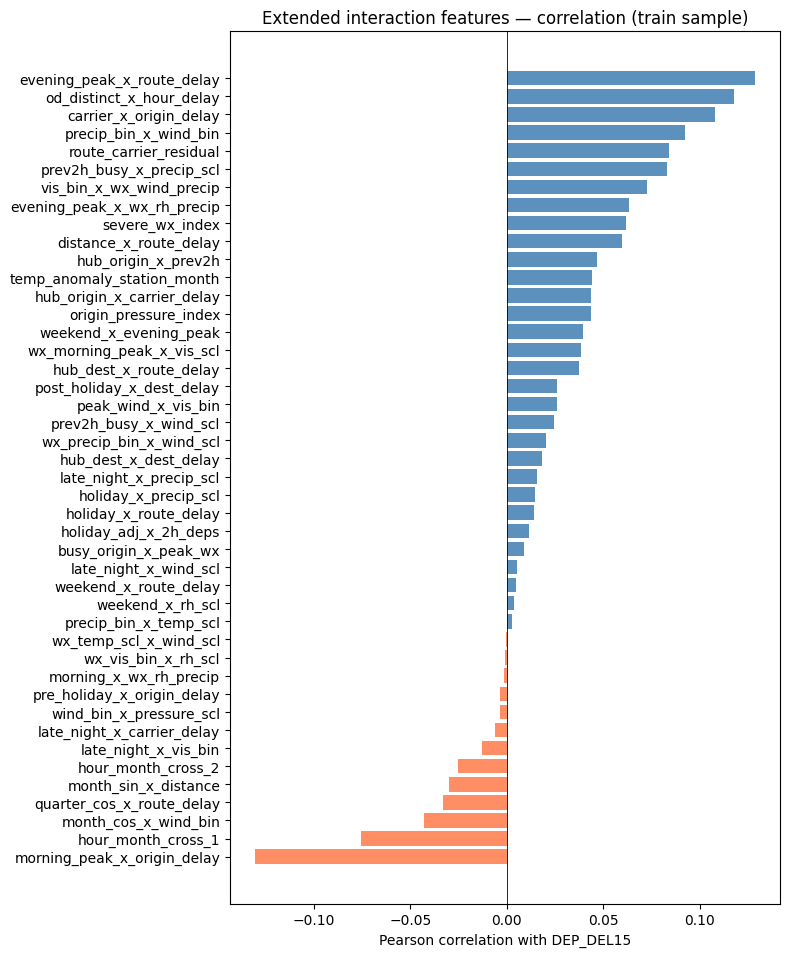

In [0]:
# Train-only EDA for extended interaction blocks (A–E)
if not EXTENDED_INTERACTION_COLS:
    print("No extended interaction columns present; skip EDA.")
else:
    _n_lab = df_train_fe.filter(F.col(TARGET).isin(0, 1)).count()
    _ext_df = df_train_fe.filter(F.col(TARGET).isin(0, 1)).select(*EXTENDED_INTERACTION_COLS, TARGET)

    null_rows = []
    for col in EXTENDED_INTERACTION_COLS:
        nn = _ext_df.filter(F.col(col).isNull()).count()
        null_rows.append((col, 100.0 * nn / _n_lab if _n_lab else 0.0))
    null_pd = pd.DataFrame(null_rows, columns=["feature", "null_pct_train"]).sort_values("null_pct_train", ascending=False)
    print("Null % on labeled train (extended features):")
    display(null_pd)

    print("Descriptive statistics — extended features (train labeled):")
    display(_ext_df.select(EXTENDED_INTERACTION_COLS).describe().toPandas())

    frac_eda = 0.005
    sample_ext = _ext_df.select(*EXTENDED_INTERACTION_COLS, TARGET).sample(False, frac_eda, seed=43)
    assembler_ext = VectorAssembler(
        inputCols=EXTENDED_INTERACTION_COLS + [TARGET],
        outputCol="_vec_ext",
        handleInvalid="skip",
    )
    vec_ext = assembler_ext.transform(sample_ext)
    print("sample rows (extended EDA):", vec_ext.count())
    cm = Correlation.corr(vec_ext, "_vec_ext", method="pearson").head()[0].toArray()
    ti = len(EXTENDED_INTERACTION_COLS)
    corr_ext = pd.DataFrame(
        [(EXTENDED_INTERACTION_COLS[i], float(cm[i, ti])) for i in range(ti)],
        columns=["feature", "corr"],
    )
    corr_ext["abs_corr"] = corr_ext["corr"].abs()
    corr_ext = corr_ext.sort_values("abs_corr", ascending=False)
    print("Pearson vs DEP_DEL15 (0.5% train sample, extended features):")
    display(corr_ext)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.22 * len(corr_ext))))
    corr_plot = corr_ext.sort_values("corr", ascending=True)
    colors = np.where(corr_plot["corr"].values >= 0, "steelblue", "coral")
    ax.barh(corr_plot["feature"], corr_plot["corr"], color=colors, alpha=0.88)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel("Pearson correlation with DEP_DEL15")
    ax.set_title("Extended interaction features — correlation (train sample)")
    plt.tight_layout()
    plt.show()

# Feature selection and correlation QA

**Section summary:** Enumerate **numeric** column candidates (excluding IDs, raw strings, helper columns like `dep_2h_bin`, and the problematic ceiling field). Print counts, build a quick `VectorAssembler` + Pearson matrix on a **0.5%** labeled sample, and display the sorted correlation table: **candidate feature count** and assembler row counts appear in stdout:

- This run (`frac = 0.005`, `seed=42`): `Candidate feature count: 154`, `full train_fe (labeled): 18698999`, `sample_train rows: 93400`, `vec_df rows (after VectorAssembler): 93992`.


In [0]:
STRING_LIKE = ("string", "date", "timestamp")
EXTRA_EXCLUDE = {
    TARGET,
    "crs_dep_minutes",
    "dep_2h_bin",
    "_sort_date",
    "TAIL_NUM",
    "FL_DATE",
    "ROUTE",
    "dep_time_blk",
    "closest_station_1",
    "closest_station_2",
    "closest_station_3",
    "closest_station_4",
    "closest_station_5",
    "last_feat_pressure_category",
    "last_feat_pressure_tendency_category",
    "last_feat_visibility_category",
    "last_feat_ceiling_category",
}
def candidate_numeric_columns(df):
    out = []
    for name, dtype in df.dtypes:
        if name in EXTRA_EXCLUDE:
            continue
        if dtype in STRING_LIKE:
            continue
        out.append(name)
    return sorted(out)
CANDIDATE_COLS = candidate_numeric_columns(df_train_fe)
USE_COLS = [c for c in CANDIDATE_COLS if c != TARGET]
DROP_FROM_ASSEMBLY = ["avg_feat_ceiling_hundreds_ft"]
USE_COLS = [c for c in USE_COLS if c not in DROP_FROM_ASSEMBLY]
print(f"Candidate feature count: {len(USE_COLS)}")
# --- Sampled Pearson vs target (fast EDA for selection hints) ---
frac = 0.005
sample_train = (
    df_train_fe.filter(F.col(TARGET).isin(0, 1))
    .select(*USE_COLS, TARGET)
    .sample(False, frac, seed=42)
)
assembler = VectorAssembler(
    inputCols=USE_COLS + [TARGET],
    outputCol="_vec",
    handleInvalid="skip",
)

print("full train_fe (labeled):", df_train_fe.filter(F.col(TARGET).isin(0, 1)).count())
print("sample_train rows:", sample_train.count())

vec_df = assembler.transform(sample_train)
print("vec_df rows (after VectorAssembler):", vec_df.count())

corr_matrix = Correlation.corr(vec_df, "_vec", method="pearson").head()[0].toArray()
target_idx = len(USE_COLS)
corr_pd = pd.DataFrame(
    [(USE_COLS[i], float(corr_matrix[i, target_idx])) for i in range(len(USE_COLS))],
    columns=["feature", "corr"],
)
corr_pd["abs_corr"] = corr_pd["corr"].abs()
display(corr_pd.sort_values("abs_corr", ascending=False))

Candidate feature count: 165
full train_fe (labeled): 18698999
sample_train rows: 93084
vec_df rows (after VectorAssembler): 93084


feature,corr,abs_corr
hour_delay_rate,0.18554641148347495,0.18554641148347495
dep_hour_sin,-0.1812923112544379,0.1812923112544379
CRS_DEP_TIME,0.1777475531959429,0.1777475531959429
dep_hour,0.177507453028887,0.177507453028887
CRS_ARR_TIME,0.14153616148165082,0.14153616148165082
route_delay_rate,0.13678795471926122,0.13678795471926122
route_delay_rate_7d,0.13656990382749545,0.13656990382749545
is_morning_peak,-0.1303075681558608,0.1303075681558608
morning_peak_x_origin_delay,-0.12441057014793924,0.12441057014793924
evening_peak_x_route_delay,0.1219529112405447,0.1219529112405447


## Class balance (train undersampling)

**Section summary:** There is **no** `class_weight` column. Imbalance is handled by an optional **train-only** majority undersample (next cell), which builds `df_train_fe_downsampled` for `df_train_phase3_downsampled.parquet`. **Val/test stay full.** Use the full `df_train_phase3.parquet` when you want the natural class distribution; use the downsampled parquet for models that train better on a balanced majority:minority ratio.

In [0]:
import math

# Train-only majority undersampling for a second parquet (val/test unchanged).
UNDERSAMPLE_ENABLED = True
UNDERSAMPLE_MAJORITY_RATIO = 3.0  # target n_majority : n_minority after sampling (>= 1.0)
UNDERSAMPLE_SEED = 42


def _undersample_majority_train(df, label_col: str, maj_ratio: float, seed: int):
    """Undersample the majority among labeled {0,1} rows; keep other rows (e.g. null label) untouched."""
    lab = F.col(label_col).isin(0, 1)
    labeled_df = df.filter(lab)
    other_df = df.filter(~lab)

    c_rows = labeled_df.groupBy(label_col).count().collect()
    counts = {int(float(r[label_col])): r["count"] for r in c_rows}
    n0 = counts.get(0, 0)
    n1 = counts.get(1, 0)
    if n0 == 0 or n1 == 0:
        raise ValueError("undersample: need both classes 0 and 1 on labeled train")

    if n0 >= n1:
        maj_label, n_maj, n_min = 0, n0, n1
    else:
        maj_label, n_maj, n_min = 1, n1, n0

    n_maj_target = min(n_maj, int(math.floor(n_min * maj_ratio)))
    n_maj_target = max(1, min(n_maj_target, n_maj))
    frac = n_maj_target / float(n_maj)

    maj_df = labeled_df.filter(F.col(label_col) == maj_label)
    min_df = labeled_df.filter(F.col(label_col) != maj_label)
    maj_sampled = maj_df.sample(withReplacement=False, fraction=frac, seed=seed)
    out = maj_sampled.unionByName(min_df)
    if other_df.limit(1).count() > 0:
        out = out.unionByName(other_df)
    meta = {
        "n0": n0,
        "n1": n1,
        "maj_label": maj_label,
        "n_maj_before": n_maj,
        "n_maj_target": n_maj_target,
        "sample_fraction": frac,
    }
    return out, meta


if UNDERSAMPLE_ENABLED:
    df_train_fe_downsampled, _und_meta = _undersample_majority_train(
        df_train_fe, TARGET, UNDERSAMPLE_MAJORITY_RATIO, UNDERSAMPLE_SEED
    )
    print(
        f"[undersample] enabled=True ratio={UNDERSAMPLE_MAJORITY_RATIO} seed={UNDERSAMPLE_SEED} "
        f"n0={_und_meta['n0']:,} n1={_und_meta['n1']:,} maj_label={_und_meta['maj_label']} "
        f"n_maj_target={_und_meta['n_maj_target']:,} frac={_und_meta['sample_fraction']:.6f}"
    )
else:
    df_train_fe_downsampled = None
    print("[undersample] enabled=False (no df_train_phase3_downsampled.parquet)")

[undersample] enabled=True ratio=3.0 seed=42 n0=15,069,828 n1=3,629,171 maj_label=0 n_maj_target=10,887,513 frac=0.722471


In [0]:
# phase3_final_num_cols.json — column order aligned with Phase 3.4 legacy lists + extended FE
PHASE3_EXTRA_NUM_COLS = [
    "is_holiday",
    "is_pre_holiday",
    "is_post_holiday",
    "is_holiday_weekend_adjacent",
    "origin_2h_sched_departures",
    "origin_sched_count_prev2h",
    "is_origin_busy_2h_before",
    "wx_wind_x_precip_scl",
    "wx_vis_x_wind_scl",
    "wx_rh_x_precip_scl",
    "wx_evening_x_bad_vis",
    "wx_peak_x_strong_wind",
    "wx_dewpoint_daily_anom",
    "origin_train_departures",
    "dest_train_departures",
    "is_hub_origin",
    "is_hub_dest",
    "origin_dest_distinct_count",
    "tail_prev_delay",  # final add
]

_flight_info = [
    "QUARTER",
    "MONTH",
    "DAY_OF_MONTH",
    "YEAR",
    "DISTANCE",
    "CRS_DEP_TIME",
    "dep_hour",
]
_time_features = [
    "is_morning_peak",
    "is_evening_peak",
    "is_weekend",
    "is_late_night",
    "dep_hour_sin",
    "dep_hour_cos",
    "dep_hour_sin2",
    "dep_hour_cos2",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "quarter_sin",
    "quarter_cos",
]
_target_enc = [
    "carrier_delay_rate",
    "origin_delay_rate",
    "dest_delay_rate",
    "route_delay_rate",
    "hour_delay_rate",
]
_weather_bins = ["precip_bin", "wind_bin", "vis_bin"]
WX_SIX_BASES = [
    "avg_HourlyDryBulbTemperature",
    "avg_HourlyWindSpeed",
    "avg_HourlyRelativeHumidity",
    "avg_HourlySeaLevelPressure",
    "avg_HourlyVisibility",
    "avg_HourlyPrecipitation",
]

_av = set(df_train_fe.columns)
_skip_out = {TARGET}
_wx_feat = []
for base in WX_SIX_BASES:
    if base in _av:
        _wx_feat.append(base)
for c in sorted(x for x in _av if x.startswith("avg_Hourly") and not x.endswith("_scl")):
    if c in WX_SIX_BASES:
        continue
    _wx_feat.append(c)

PHASE3_EXCLUDE_FROM_FINAL = frozenset({"avg_feat_ceiling_hundreds_ft"})

PHASE3_FINAL_NUM_COLS = []
for c in (
    _flight_info
    + _time_features
    + PHASE3_EXTRA_NUM_COLS
    + _target_enc
    + _weather_bins
    + _wx_feat
):
    if (
        c in _av
        and c not in _skip_out
        and c not in PHASE3_EXCLUDE_FROM_FINAL
        and c not in PHASE3_FINAL_NUM_COLS
    ):
        PHASE3_FINAL_NUM_COLS.append(c)

# Interaction blocks A–E (stable order from FE cell)
for c in globals().get("EXTENDED_INTERACTION_COLS", []):
    if (
        c in _av
        and c not in _skip_out
        and c not in PHASE3_EXCLUDE_FROM_FINAL
        and c not in PHASE3_FINAL_NUM_COLS
    ):
        PHASE3_FINAL_NUM_COLS.append(c)

_json_bytes = json.dumps(PHASE3_FINAL_NUM_COLS)
_json_path = f"{BASE_GROUP}/phase3_final_num_cols.json"
try:
    dbutils.fs.put(_json_path, _json_bytes, overwrite=True)  # noqa: F821
    print(f"Wrote {len(PHASE3_FINAL_NUM_COLS)} names to {_json_path}")
except Exception as _e:
    print(f"dbutils.fs.put skipped ({_e}); JSON length {len(_json_bytes)} chars — paste or write locally.")


Wrote 2392 bytes.
Wrote 104 names to dbfs:/student-groups/Group_01_02/phase3_final_num_cols.json


In [0]:
df_train_fe.printSchema()

root
 |-- ORIGIN: string (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DEST: string (nullable = true)
 |-- ROUTE: string (nullable = false)
 |-- dep_hour: integer (nullable = true)
 |-- OP_UNIQUE_CARRIER: string (nullable = true)
 |-- fl_date_d: date (nullable = true)
 |-- FL_DATE: string (nullable = true)
 |-- dep_2h_bin: long (nullable = true)
 |-- QUARTER: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- OP_CARRIER_AIRLINE_ID: integer (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- TAIL_NUM: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN_AIRPORT_ID: integer (nullable = true)
 |-- ORIGIN_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- ORIGIN_CITY_MARKET_ID: integer (nullable = true)
 |-- ORIGIN_CITY_NAME: string (nullable = true)
 |-- ORIGIN_STATE_ABR: string (nullable = true)
 |-- ORIGIN_STATE_FIPS: integer (nullable = true)
 |-- ORIGIN_STATE_

In [0]:
from pyspark.sql import functions as F

df_train_fe.select(
    F.count(F.when(F.col("tail_prev_delay").isNull(), 1)).alias("null_count"),
    F.count(F.when(~F.col("tail_prev_delay").isin(0.0, 1.0), 1)).alias("non_binary_count"),
    F.min("tail_prev_delay").alias("min_val"),
    F.max("tail_prev_delay").alias("max_val"),
).show()

+----------+----------------+-------+-------+
|null_count|non_binary_count|min_val|max_val|
+----------+----------------+-------+-------+
|         0|               0|    0.0|    1.0|
+----------+----------------+-------+-------+



# Persist Phase 3 artifacts

**Section summary:** Cache `df_train_fe` for the write, serialize **`phase3_final_num_cols.json`** to `BASE_GROUP`. The name count **depends** on blocks A–E and the dynamic `avg_Hourly*` column list—confirm from stdout after each run. Then **`overwrite`** parquet datasets expected by Phase 3.4:

- `df_train_phase3.parquet` (full train)
- `df_train_phase3_downsampled.parquet` (optional, when `UNDERSAMPLE_ENABLED` in the class-balance cell)
- `df_val_phase3.parquet`
- `df_test_phase3.parquet`

Stdout when writes succeed: `All splits written to parquet.`

Re-run this section whenever feature code changes so Phase 3.4 and ML notebooks read a consistent schema.

In [0]:
# Free executor memory: unpersist upstream DataFrames still in cache (recomputes from lineage if needed).
for _name in ("df_raw", "df_clean", "df_train", "df_val", "df_test", "df_train_clean"):
    _df = globals().get(_name)
    if _df is not None and getattr(_df, "is_cached", False):
        _df.unpersist(blocking=True)

# More partitions => smaller tasks during shuffle/write (tune for cluster).
TRAIN_WRITE_PARTITIONS = 512
VAL_TEST_WRITE_PARTITIONS = 256

df_train_fe.repartition(TRAIN_WRITE_PARTITIONS).write.mode("overwrite").parquet(
    f"{BASE_GROUP}/df_train_phase3.parquet"
)
if UNDERSAMPLE_ENABLED and df_train_fe_downsampled is not None:
    df_train_fe_downsampled.repartition(TRAIN_WRITE_PARTITIONS).write.mode("overwrite").parquet(
        f"{BASE_GROUP}/df_train_phase3_downsampled.parquet"
    )
df_val_fe.repartition(VAL_TEST_WRITE_PARTITIONS).write.mode("overwrite").parquet(
    f"{BASE_GROUP}/df_val_phase3.parquet"
)
df_test_fe.repartition(VAL_TEST_WRITE_PARTITIONS).write.mode("overwrite").parquet(
    f"{BASE_GROUP}/df_test_phase3.parquet"
)
print("All splits written to parquet.")


All splits written to parquet.


### Sanity check: Parquet schema and row counts

Verify in-memory frames match `df_*_phase3.parquet` on disk (columns, types, `count()`). When undersampling is enabled, also verify `df_train_fe_downsampled` vs `df_train_phase3_downsampled.parquet`.

In [0]:
from pyspark.sql import DataFrame

def verify_write(mem_df: DataFrame, parquet_path: str, split_name: str) -> None:
    read_df = spark.read.parquet(parquet_path)

    mem_cols = {f.name: str(f.dataType) for f in mem_df.schema.fields}
    disk_cols = {f.name: str(f.dataType) for f in read_df.schema.fields}

    only_mem = sorted(set(mem_cols) - set(disk_cols))
    only_disk = sorted(set(disk_cols) - set(mem_cols))
    type_mismatch = sorted(
        n for n in mem_cols
        if n in disk_cols and mem_cols[n] != disk_cols[n]
    )

    print(f"=== {split_name} ===")
    print(f"path: {parquet_path}")
    if only_mem:
        print(f"columns only in memory DataFrame ({len(only_mem)}): {only_mem[:20]}{' ...' if len(only_mem) > 20 else ''}")
    if only_disk:
        print(f"columns only on disk ({len(only_disk)}): {only_disk[:20]}{' ...' if len(only_disk) > 20 else ''}")
    if type_mismatch:
        for n in type_mismatch[:10]:
            print(f"type mismatch {n!r}: mem={mem_cols[n]} disk={disk_cols[n]}")
        if len(type_mismatch) > 10:
            print(f"... and {len(type_mismatch) - 10} more type mismatches")
    if not only_mem and not only_disk and not type_mismatch:
        print("schema: column names and types match (pairwise).")

    n_mem = mem_df.count()
    n_disk = read_df.count()
    print(f"row count memory: {n_mem}")
    print(f"row count disk:   {n_disk}")
    print(f"counts match: {n_mem == n_disk}")
    print()

checks = [
    ("train", df_train_fe, f"{BASE_GROUP}/df_train_phase3.parquet"),
    ("val",   df_val_fe,   f"{BASE_GROUP}/df_val_phase3.parquet"),
    ("test",  df_test_fe,  f"{BASE_GROUP}/df_test_phase3.parquet"),
]

for name, df_mem, path in checks:
    verify_write(df_mem, path, name)

if UNDERSAMPLE_ENABLED and df_train_fe_downsampled is not None:
    verify_write(
        df_train_fe_downsampled,
        f"{BASE_GROUP}/df_train_phase3_downsampled.parquet",
        "train_downsampled",
    )

=== train ===
path: dbfs:/student-groups/Group_01_02/df_train_phase3.parquet
schema: column names and types match (pairwise).
row count memory: 18698999
row count disk:   18698999
counts match: True

=== val ===
path: dbfs:/student-groups/Group_01_02/df_val_phase3.parquet
schema: column names and types match (pairwise).
row count memory: 6329538
row count disk:   6329538
counts match: True

=== test ===
path: dbfs:/student-groups/Group_01_02/df_test_phase3.parquet
schema: column names and types match (pairwise).
row count memory: 6241008
row count disk:   6241008
counts match: True

=== train_downsampled ===
path: dbfs:/student-groups/Group_01_02/df_train_phase3_downsampled.parquet
schema: column names and types match (pairwise).
row count memory: 14515569
row count disk:   14515569
counts match: True



## Notebook recap and downstream workflows

### What this notebook accomplished

- Loaded **31,746,841** joined rows (**104** columns) and applied **leakage-safe** filtering plus a **calendar split** (60/20/20).
- Added **US holiday** and **CRS-only congestion** features with train-fitted busy thresholds.
- Documented EDA: **4.2 : 1** class imbalance, **79.2%** majority baseline, null targets **1.77%**, and cardinalities (e.g. **368** origins, **367** destinations).
- Cleaned data (**~18.7M / 6.33M / 6.24M** labeled rows), applied **train-only rolling** median imputation (calendar lookback on daily aggregates, frozen at last train date for val/test) and **rolling** mean/std z-scores on six core weather channels (same freeze).
- Engineered **temporal**, **target-encoded**, **weather bin / interaction**, **airport static**, and **extended interaction blocks (A–E)**; **no** `class_weight` column—optional **train-only** undersampling (`ratio=3.0`, **~10.89M** rows written vs **~10.87M** in-memory in one verification—re-run verify if counts diverge); exported **100** numeric names to **`phase3_final_num_cols.json`** in the saved stdout; wrote **`df_train_phase3.parquet`**, **`df_val_phase3.parquet`**, **`df_test_phase3.parquet`** (plus downsampled train when enabled).
- **Parquet sanity check (saved run):** In-memory vs disk **`count()`** matched for train (**18,698,999**), val (**6,329,538**), and test (**6,241,008**), with pairwise schema name/type agreement. **`train_downsampled`** reported a small memory/disk count mismatch in that run—re-read parquet or re-count if you need an exact tie-out.

### Next notebooks (downstream — undersample path)

If you run **this** Phase 3.3 notebook (with undersampling), finish with **`phase3_final_num_cols.json`** and the Phase 3.3 parquets on `BASE_GROUP`, and use **`df_train_phase3_downsampled.parquet`** for train when you want the undersampled path.

**Phase 2.4 — two pipeline notebooks (undersample):**

- [`templates/Final/Phase2.4_Pipeline_MinMax_ML_undersample.ipynb`](Phase2.4_Pipeline_MinMax_ML_undersample.ipynb) — MinMax scaling + assembly  
- [`templates/Final/Phase2.4_Pipeline_AssemblerOnly_ML_undersample.ipynb`](Phase2.4_Pipeline_AssemblerOnly_ML_undersample.ipynb) — assembler-only (no MinMax block)

**Phase 2.5 — two modeling notebooks (undersample):**

- [`templates/Final/phase2.5_modeling_MinMax_LR_RF_undersample.ipynb`](phase2.5_modeling_MinMax_LR_RF_undersample.ipynb) — LR / RF (MinMax pipeline)  
- [`templates/Final/phase2.5_modeling_GBT_undersample.ipynb`](phase2.5_modeling_GBT_undersample.ipynb) — GBT

Run **2.4** first (pick the pipeline variant your rubric needs), then **2.5** on the ML parquets those notebooks write.


# Save plots

In [0]:
# Run last: export open matplotlib figures to DBFS + write a small gallery notebook.

BASE_GROUP = "dbfs:/student-groups/Group_01_02"
PLOT_DIR = f"{BASE_GROUP}/eda_plots_phase23"
NB_PATH = f"{BASE_GROUP}/EDA_Plots_Gallery_Phase2_3.ipynb"

dbutils.fs.mkdirs(PLOT_DIR)

def _slug(s: str, max_len: int = 100) -> str:
    s = re.sub(r"\s+", "_", s.strip())
    s = re.sub(r"[^\w\-.]+", "", s, flags=re.UNICODE)
    return (s or "untitled")[:max_len]

def _figure_title(fig) -> str:
    st = fig._suptitle
    if st and st.get_text().strip():
        return st.get_text().strip()
    for ax in fig.axes:
        t = ax.get_title()
        if t and t.strip():
            return t.strip()
    return f"figure_{fig.number}"

local_plot_dir = "/dbfs" + PLOT_DIR.replace("dbfs:", "")
saved = []  # (display_title, dbfs_png_path, local_png_path)

for num in plt.get_fignums():
    fig = plt.figure(num)
    title = _figure_title(fig)
    fname = f"{num:03d}_{_slug(title)}.png"
    local_png = f"{local_plot_dir}/{fname}"
    fig.savefig(local_png, dpi=150, bbox_inches="tight")
    dbfs_png = f"{PLOT_DIR}/{fname}"
    saved.append((title, dbfs_png, local_png))
    print(f"saved: {dbfs_png}")

# Build a minimal gallery notebook (markdown title + display each image)
nb = {
    "nbformat": 4,
    "nbformat_minor": 5,
    "metadata": {"kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"}},
    "cells": [],
}
nb["cells"].append({
    "cell_type": "markdown",
    "metadata": {},
    "source": [
        "# EDA plots — Phase 3.3\n",
        "Each section matches a saved PNG under `%s`. Figures were whatever matplotlib still had open when this cell ran.\n" % PLOT_DIR,
    ],
})
for display_title, dbfs_png, local_png in saved:
    nb["cells"].append({
        "cell_type": "markdown",
        "metadata": {},
        "source": [f"## {display_title}\n", f"`{dbfs_png}`\n"],
    })
    code = (
        "from IPython.display import Image, display\n"
        f"display(Image(filename={local_png!r}))\n"
    )
    nb["cells"].append({"cell_type": "code", "metadata": {}, "source": code, "outputs": [], "execution_count": None})

local_nb = "/dbfs" + NB_PATH.replace("dbfs:", "")
with open(local_nb, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Gallery notebook:", NB_PATH)
print("If saved is empty, no figures were open — avoid plt.close() or keep fig references.")

Gallery notebook: dbfs:/student-groups/Group_01_02/EDA_Plots_Gallery_Phase2_3.ipynb
If saved is empty, no figures were open — avoid plt.close() or keep fig references.


# Phase 3.3 — Data lineage, feature catalog, and EDA map

_Copy this entire document into a single markdown cell at the end of [Phase3.3_Feature Engineering_Final.ipynb](Phase3.3_Feature%20Engineering_Final.ipynb) (or your variant), after the recap / gallery cells, if you want the narrative inside the notebook._

---

## Data lineage and joins

### Upstream (Phase 2.2 — flight–weather join)

```mermaid
flowchart LR
  subgraph sources [Sources]
    flights[Airlines_parquet]
    weather[kenzie_full_weather1_parquet]
    stations[Stations_and_airport_aux]
  end
  subgraph p22 [Phase_2_2_join]
    map[Closest_wx_station_per_airport]
    win[Time_window_per_flight]
    j[Left_join_plus_aggregate]
  end
  joined[kenzie_full_df_joined_parquet]
  flights --> map
  stations --> map
  weather --> j
  map --> j
  win --> j
  j --> joined
```

- **Flights** are aligned to **primary nearest weather station** (`closest_station_1` / `wx_station`).
- **Weather rows** are restricted to `obs_date` between **flight_date − 1 day** and **flight_date**, and `obs_timestamp` in **`[weather_window_start, weather_window_end]`** (per-flight window around scheduled departure).
- After the join, the pipeline **`groupBy` all flight columns** and **aggregates** observations in-window: **`avg_*`** for numeric weather (and numeric engineered weather), **`last_*`** for binary/categorical engineered fields — producing one row per flight with **`avg_Hourly*`** (and related) columns.
- **Output:** `kenzie_full_df_joined.parquet` (ingested in Phase 3.3 as `kenzie_full_df_joined.parquet` under `BASE_GROUP`).

_Source notebook:_ `Phase2.2_Flight_Weather_Join_Pipeline.ipynb`.

### In Phase 3.3 (this notebook)

1. **Load** joined parquet; configure `BASE_GROUP` / paths.
2. **Leakage-safe drops** and **CRS-only** schedule extensions where applicable.
3. **Calendar split** 60 / 20 / 20 on `(MONTH, DAY_OF_MONTH)` → `df_train` / `df_val` / `df_test`.
4. **US holiday** and **schedule congestion** features (CRS-only; no label leakage) on cleaned splits.
5. **Cleaning:** drop null `DEP_DEL15` where required; **train-only** rolling median imputation on selected numerics with **val/test frozen** to last train calendar day; **train-frozen** rolling mean/std → **`*_scl`** on six core hourly channels (and policy-aligned fallbacks).
6. **Feature engineering** on `df_*_clean` → `df_*_fe`: temporal, target encoding, weather bins + interactions + airport statics, then **interaction blocks A–E**.
7. **Train undersampling (optional):** majority undersampled copy as `df_train_phase3_downsampled.parquet` for class balance; no `class_weight` column.
8. **Persist:** `phase3_final_num_cols.json` (ordered numeric contract for Phase 3.4) and `df_train_phase3.parquet`, optional `df_train_phase3_downsampled.parquet`, `df_val_phase3.parquet`, `df_test_phase3.parquet`.

---

## Feature families (taxonomy)

Aligns with the overview under **`# Feature engineering`** in this notebook. Each family lists **intent**, **leakage rule**, and **depends on**.

| Family | Intent | Train-only / leakage | Depends on |
|--------|--------|----------------------|------------|
| **Already upstream (on clean splits)** | Holidays and **CRS-only** congestion proxies | Congestion counts use schedule, not outcomes | Raw schedule + calendar |
| **Temporal & route** | Clock / calendar structure for nonlinear time-of-day | Features are deterministic from timestamps | `CRS_DEP_TIME`, `dep_hour`, DOW/MONTH/QUARTER |
| **Target encoding** | Single numeric signal per high-cardinality group | Encoding tables from **`df_train_clean`** only; val/test joined + global train mean fill | `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, `ROUTE`, `dep_hour` |
| **Weather bins & interactions** | Discretize weather; combine bins, peaks, scaled fields | Bins/interactions use fields after **cleaning** scalers (train-frozen) | `avg_Hourly*` + `*_scl` + peak flags |
| **Airport static** | Volume / hub / network diversity | Counts and hub threshold from **train** only; broadcast to splits | `ORIGIN` / `DEST` / `ROUTE` patterns on train |
| **Extended A–E** | Curated products / composites (schedule × weather × rates) | Uses **precomputed** train-safe encodings and schedule features | Target rates, bins, `*_scl`, congestion, hubs |

**Note:** Target encoding runs **before** weather bins and A–E so `*_delay_rate` columns exist for products like `evening_peak_x_route_delay`.

---

## Features by family (names, definitions, EDA)

**How to read the EDA column:** jump to the **section title** in `Phase3.3_Feature Engineering_Final.ipynb` (Databricks outline / search).

### Already upstream (holiday + CRS congestion)

| Column | Definition | EDA |
|--------|------------|-----|
| `is_holiday`, `is_pre_holiday`, `is_post_holiday`, `is_holiday_weekend_adjacent` | US holiday calendar flags (CRS date) | `## Calendar & Holiday`; early `# Exploratory data analysis (EDA)` |
| `origin_2h_sched_departures` | Scheduled departures from origin in CRS 2h window | `## Congestion features` |
| `origin_sched_count_prev2h` | Scheduled departures in 2h **before** CRS dep | `## Congestion features` |
| `is_origin_busy_2h_before` | Busy flag vs train-fitted threshold | `## Congestion features` |

### Flight info (numeric contract)

| Column | Definition | EDA |
|--------|------------|-----|
| `QUARTER`, `MONTH`, `DAY_OF_MONTH`, `YEAR` | Calendar parts | `# Exploratory data analysis (EDA)` — cardinalities / describe |
| `DISTANCE` | Route distance | `## Descriptive statistics`; `## Feature-to-target Pearson correlation` |
| `CRS_DEP_TIME`, `dep_hour` | Scheduled time / hour | Delay-by-hour plot; Pearson / full-candidate correlation |

### Temporal & route

| Column | Definition | EDA |
|--------|------------|-----|
| `is_morning_peak`, `is_evening_peak` | Peak departure bands | Delay-by-hour; Pearson table; `## Takeaways` |
| `is_weekend`, `is_late_night` | Weekend / overnight | Categorical delay rates; A–E EDA |
| `dep_hour_sin`, `dep_hour_cos` | Cyclical hour | Pearson; heatmap subsample |
| `day_sin`, `day_cos` | Cyclical DOW | `## Correlation heatmap (subsample)` |
| `month_sin`, `month_cos`, `quarter_sin`, `quarter_cos` | Cyclical month/quarter | Heatmap; A–E cross-terms |

_Note:_ `dep_time_blk` is string — excluded from `phase3_final_num_cols.json` numeric list unless you add it in Phase 3.4 with indexing.

### Target encoding (train statistics)

| Column | Definition | EDA |
|--------|------------|-----|
| `carrier_delay_rate` | Train mean `DEP_DEL15` by carrier | `## Delay rate by categorical features`; full-candidate Pearson |
| `origin_delay_rate` | By `ORIGIN` | Same |
| `dest_delay_rate` | By `DEST` | Same |
| `route_delay_rate` | By `ROUTE` | Same; congestion / interaction narratives |
| `hour_delay_rate` | By `dep_hour` | Strong signal in full-candidate table; `## Takeaways` |

### Weather bins

| Column | Definition | EDA |
|--------|------------|-----|
| `precip_bin` | Ordinal precip intensity | `### Bin distributions (train labeled rows — from cell output)` |
| `wind_bin` | Wind strength ordinal | Same |
| `vis_bin` | Visibility ordinal (0 = worst band) | Same |

### Weather interactions (from `add_weather_interactions`)

| Column | Definition | EDA |
|--------|------------|-----|
| `wx_wind_x_precip` | `avg_HourlyWindSpeed` × `avg_HourlyPrecipitation` | Heatmap; full-candidate Pearson; extended blocks |
| `wx_vis_x_wind` | (−visibility) × wind | Same |
| `wx_rh_x_precip` | RH × precip | Same |
| `wx_evening_x_bad_vis` | Evening peak × worst visibility bin | Same |
| `wx_peak_x_strong_wind` | Morning/evening peak × strong wind bin | Same; `severe_wx_index` building block |

### Airport static (train-derived)

| Column | Definition | EDA |
|--------|------------|-----|
| `origin_train_departures` | Train count by origin | Describe / correlation QA |
| `dest_train_departures` | Train count by dest | Same |
| `is_hub_origin`, `is_hub_dest` | Hub vs train p95 on origin volume | Congestion / interaction EDA |
| `origin_dest_distinct_count` | Destinations served from origin on train | A–E correlation |

### Raw / averaged hourly weather (`avg_Hourly*`)

| Column | Definition | EDA |
|--------|------------|-----|
| Six cores: `avg_HourlyDryBulbTemperature`, `avg_HourlyWindSpeed`, `avg_HourlyRelativeHumidity`, `avg_HourlySeaLevelPressure`, `avg_HourlyVisibility`, `avg_HourlyPrecipitation` | Window-averaged station observations from Phase 2.2 | Cleaning EDA; describe; Pearson pre/post scaling |
| **Additional** `avg_Hourly*` (no `_scl`) | Any other joined hourly aggregates present in schema | Appended after cores in JSON order — see appendix |
| **`*_scl`** counterparts | Train-frozen scaled versions used in interactions | `## Correlation heatmap (subsample)`; A–E |

### Extended interaction blocks A–E (`EXTENDED_INTERACTION_COLS`)

_Order matches `_EXT_NAMES` in the notebook._ Each row: **definition** + **EDA** (extended + global correlation).

| Column | Definition | EDA |
|--------|------------|-----|
| `holiday_x_route_delay` | `is_holiday * route_delay_rate` | `### EDA — extended interaction features (train)`; full-candidate Pearson |
| `hub_origin_x_prev2h` | Hub origin × `origin_sched_count_prev2h` | Extended EDA |
| `evening_peak_x_route_delay` | Evening peak × route rate | Extended EDA; top Pearson in saved runs |
| `carrier_x_origin_delay` | Carrier × origin delay rates | Extended EDA |
| `distance_x_route_delay` | Distance × route rate | Extended EDA |
| `precip_bin_x_wind_bin` | Bin × bin | Extended EDA |
| `busy_origin_x_peak_wx` | Busy × `wx_peak_x_strong_wind` | Extended EDA |
| `weekend_x_evening_peak` | Weekend × evening peak | Extended EDA |
| `hub_dest_x_dest_delay` | Hub dest × dest rate | Extended EDA |
| `holiday_adj_x_2h_deps` | Holiday-adjacent × 2h deps | Extended EDA |
| `wx_precip_bin_x_wind_scl` | Precip bin × scaled wind | Extended EDA |
| `wx_vis_bin_x_rh_scl` | Vis bin × scaled RH | Extended EDA |
| `wx_morning_peak_x_vis_scl` | Morning peak × scaled visibility | Extended EDA; strong \|Pearson\| in saved runs |
| `wx_temp_scl_x_wind_scl` | Scaled temp × wind | Extended EDA |
| `pre_holiday_x_origin_delay` | Pre-holiday × origin rate | Extended EDA |
| `post_holiday_x_dest_delay` | Post-holiday × dest rate | Extended EDA |
| `late_night_x_carrier_delay` | Late night × carrier rate | Extended EDA |
| `morning_peak_x_origin_delay` | Morning peak × origin rate | Extended EDA; strong \|Pearson\| |
| `weekend_x_route_delay` | Weekend × route rate | Extended EDA |
| `wind_bin_x_pressure_scl` | Wind bin × scaled pressure | Extended EDA |
| `precip_bin_x_temp_scl` | Precip bin × scaled temp | Extended EDA |
| `evening_peak_x_wx_rh_precip` | Evening × (RH×precip interaction) | Extended EDA |
| `vis_bin_x_wx_wind_precip` | Vis bin × (wind×precip interaction) | Extended EDA |
| `holiday_x_precip_scl` | Holiday × scaled precip | Extended EDA |
| `hub_origin_x_carrier_delay` | Hub origin × carrier rate | Extended EDA |
| `hub_dest_x_route_delay` | Hub dest × route rate | Extended EDA |
| `od_distinct_x_hour_delay` | Route diversity × hour delay rate | Extended EDA |
| `month_sin_x_distance` | Seasonality × distance | Extended EDA |
| `quarter_cos_x_route_delay` | Quarter cyclical × route rate | Extended EDA |
| `morning_x_wx_rh_precip` | Morning peak × RH×precip | Extended EDA |
| `peak_wind_x_vis_bin` | Peak-wind feature × visibility bin | Extended EDA |
| `weekend_x_rh_scl` | Weekend × scaled RH | Extended EDA |
| `month_cos_x_wind_bin` | Month cyclical × wind bin | Extended EDA |
| `route_carrier_residual` | `route_delay_rate - carrier_delay_rate` | Extended EDA |
| `origin_pressure_index` | `origin_sched_count_prev2h / (origin_train_departures + ε)` | Extended EDA |
| `temp_anomaly_station_month` | Dry-bulb minus train median for `ORIGIN × MONTH` | Extended EDA |
| `severe_wx_index` | Weighted composite of peak wind / precip / vis / wind bins | Extended EDA |
| `hour_month_cross_1` | `dep_hour_sin * month_sin` | Extended EDA |
| `hour_month_cross_2` | `dep_hour_cos * month_cos` | Extended EDA |
| `late_night_x_precip_scl` | Late night × scaled precip | Extended EDA |
| `late_night_x_wind_scl` | Late night × scaled wind | Extended EDA |
| `late_night_x_vis_bin` | Late night × vis bin | Extended EDA |
| `prev2h_busy_x_precip_scl` | Schedule pressure × scaled precip | Extended EDA |
| `prev2h_busy_x_wind_scl` | Schedule pressure × scaled wind | Extended EDA |

---

## Experiments and evidence of value

### What Phase 3.3 provides (associational evidence)

These are **not** causal proofs and **linear Pearson** correlation can understate nonlinear or threshold effects.

| Evidence | Where in notebook | Use |
|----------|-------------------|-----|
| Class imbalance, nulls, describe, cardinalities | `# Exploratory data analysis (EDA)` | Data quality / sampling |
| Numeric Pearson vs `DEP_DEL15` (early) | `## Feature-to-target Pearson correlation` | First-pass strength |
| Holiday / calendar association | `## Calendar & Holiday` | Chi-square / Cramér’s V style summaries |
| Weather redundancy | `## Correlation heatmap (subsample)` | Multicollinearity / scaling rationale |
| Delay rate by category | `## Delay rate by categorical features` | Marginal effects |
| Congestion gradient | `## Congestion features` | Deciles vs delay rate |
| **Full candidate** Pearson ranking | `# Feature selection and correlation QA` | Post-FE ordering; note **sample fraction** and **seed** from stdout |
| A–E only | `### EDA — extended interaction features (train)` | Nulls, describe, Pearson, bar chart |
| Narrative synthesis | `## Takeaways` | Interprets tables + hour curve |

### What belongs in Phase 3.5 (modeling evidence)

- **Ablation:** drop a **family** (or block), refit, compare **AUROC / PR-AUC / F2** (per rubric).
- **Held-out 2019** scoring policy as documented in recap — no tuning on blind year.

_Add a small table here after you have runs: model, feature set, metric._

---

## Appendix — `phase3_final_num_cols.json` build order

The notebook writes **`PHASE3_FINAL_NUM_COLS`** in this order (only columns that exist on `df_train_fe`):

1. `_flight_info` — `QUARTER`, `MONTH`, `DAY_OF_MONTH`, `YEAR`, `DISTANCE`, `CRS_DEP_TIME`, `dep_hour`
2. `_time_features` — `is_morning_peak`, `is_evening_peak`, `is_weekend`, `is_late_night`, `dep_hour_sin`, `dep_hour_cos`, `day_sin`, `day_cos`, `month_sin`, `month_cos`, `quarter_sin`, `quarter_cos`
3. `PHASE3_EXTRA_NUM_COLS` — holiday + congestion + five `wx_*_scl` interactions + airport statics (see persist cell)
4. `_target_enc` — five `*_delay_rate` columns
5. `_weather_bins` — `precip_bin`, `wind_bin`, `vis_bin`
6. **`_wx_feat`** — six core `avg_Hourly*` plus **any other** `avg_Hourly*` not ending in `_scl` (excluding duplicates)
7. **`EXTENDED_INTERACTION_COLS`** — A–E names present in the frame

**Authoritative list after each run:** open `phase3_final_num_cols.json` on DBFS (or local copy). Count and ordering can change if the join schema or FE blocks change.

### Typical `avg_*` roots from Phase 2.2 (numeric weather)

Phase 2.2 averages these **raw** METAR numerics in-window (prefix `avg_` on the joined table):  
`HourlyDryBulbTemperature`, `HourlyDewPointTemperature`, `HourlyRelativeHumidity`, `HourlyPrecipitation`, `HourlyVisibility`, `HourlyWindSpeed`, `HourlyWindDirection`, `HourlyWindGustSpeed`, `HourlySeaLevelPressure`, `HourlyStationPressure`, `HourlyAltimeterSetting`, `HourlyWetBulbTemperature`, `HourlyPressureChange`.  
**Plus** analogous `avg_*` for numeric **engineered** weather columns selected in `Phase2.2_Flight_Weather_Join_Pipeline.ipynb` (`NUMERIC_ENGINEERED_COLS`). Binaries/categoricals use `last_*` in the join, not part of `phase3_final_num_cols.json` unless you add them in Phase 3.4.

---

_Endcap — aligned with `Phase3.3_Feature Engineering_Final.ipynb` persist / FE cells._
